In [2]:
#SETUP

!pip install -q statsmodels openpyxl xlsxwriter
from google.colab import drive; drive.mount('/content/drive')
import os
PROJECT_DIR='/content/drive/MyDrive/PRT564_Project_Final Assessment'
OUTPUT_DIR=f'{PROJECT_DIR}/outputs_a4_final'
DATA_PATH=f'{PROJECT_DIR}/quarterly_regression_merged_dataset_rebuilt_fullhistory_pop_hs.xlsx'
os.makedirs(OUTPUT_DIR,exist_ok=True)

import math
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from scipy.stats import mode as scipy_mode
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     cross_val_score, learning_curve)

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    mean_absolute_error, mean_squared_error)
from matplotlib.patches import Patch
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']=110; sns.set_style('whitegrid')

CLASSES=['Decline','Modest Growth','Strong Growth']
CC={'Decline':'#d62728','Modest Growth':'#ff7f0e','Strong Growth':'#2ca02c'}

def map_cluster_to_class(clus, cls, k):
    labels=np.zeros_like(clus)
    for i in range(k):
        m=(clus==i)
        if m.sum()>0:
            labels[m]=scipy_mode(cls[m], keepdims=False)[0]
    return labels

def fc(n):
    if 'State_' in n and n.startswith('State_'): return '#c0392b'   #state dummies
    if 'QoQ' in n or 'Retail_QoQ' in n:          return '#16a085'   #momentum
    if '_L1' in n or '_L2' in n:                 return '#2980b9'   #lagged levels
    if 'Roll' in n or 'Rising' in n or 'IF_' in n or 'LOF' in n or 'Flag' in n: return '#9b59b6'
    if 'Population' in n: return '#e67e22'
    return '#27ae60'


#Manual repeated 10-fold StratifiedKFold CV
#Returns the array of 100 macro-F1 estimates (10 folds x 10 seeds).
def repeated_cv_f1(model, X, y, n_folds=10, n_reps=10, seed_base=42):
    scores=[]
    for r in range(n_reps):
        skf_r=StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed_base+r)
        s=cross_val_score(model, X, y, cv=skf_r, scoring='f1_macro', n_jobs=-1)
        scores.extend(s.tolist())
    return np.asarray(scores)

#Empirical 95% band from the 100 CV estimates (no external statistics dependency).
def cv_summary(scores):
    return {'mean':float(np.mean(scores)),
            'std':float(np.std(scores, ddof=1)),
            'lo':float(np.percentile(scores, 2.5)),
            'hi':float(np.percentile(scores, 97.5))}

print('Setup complete - on-syllabus build')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete - on-syllabus build


In [3]:
#LOAD AND CLEAN
df=pd.read_excel(DATA_PATH, sheet_name='State_Qtr_AllStates_FullHistory', header=2)
df.columns=df.columns.str.strip()
for c in df.columns:
    if c not in ['Quarter','Quarter_End','State','Unemployment_Series_Type']:
        df[c]=pd.to_numeric(df[c], errors='coerce')
df=df.sort_values(['State','Quarter_End']).reset_index(drop=True)
df['Quarter_End']=pd.to_datetime(df['Quarter_End'])

print(f'Shape: {df.shape} | Duplicates: {df.duplicated(subset=["State","Quarter"]).sum()}')
key=['Unemployment_Rate_QtrAvg','CPI_All_Groups_Index','Cash_Rate_QtrAvg',
     'WPI_Index_SA','State_Final_Demand_SA','Population']
print(f'Key predictors missing: {df[key].isna().sum().sum()}')
for c in ['Population','CPI_All_Groups_Index']:
    print(f'  Negative {c}: {(df[c]<0).sum()}')
print(f'Unemployment series: {df.groupby("Unemployment_Series_Type").size().to_dict()}')

#Per-variable IQR outlier counts
for col in ['Retail_Turnover_QoQ_Pct','Unemployment_Rate_QtrAvg','Cash_Rate_QtrAvg']:
    s=df[col].dropna(); q1,q3=s.quantile(0.25),s.quantile(0.75); iqr=q3-q1
    print(f'  IQR {col}: {((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum()} outliers')

#Multivariate outlier flags (Isolation Forest + LOF) kept as features
iX=df[key].dropna()
df.loc[iX.index,'IF_Outlier']=IsolationForest(contamination=0.05, random_state=42).fit_predict(iX)
df['IF_Outlier']=df['IF_Outlier'].apply(lambda x:1 if x==-1 else 0)
df.loc[iX.index,'LOF_Outlier']=LocalOutlierFactor(n_neighbors=20, contamination=0.05).fit_predict(iX)
df['LOF_Outlier']=df['LOF_Outlier'].apply(lambda x:1 if x==-1 else 0)
print(f'Isolation Forest: {df["IF_Outlier"].sum()} | LOF: {df["LOF_Outlier"].sum()} -> retained as features')


Shape: (896, 20) | Duplicates: 0
Key predictors missing: 0
  Negative Population: 0
  Negative CPI_All_Groups_Index: 0
Unemployment series: {'Original': 224, 'Seasonally Adjusted': 672}
  IQR Retail_Turnover_QoQ_Pct: 37 outliers
  IQR Unemployment_Rate_QtrAvg: 16 outliers
  IQR Cash_Rate_QtrAvg: 0 outliers
Isolation Forest: 45 | LOF: 45 -> retained as features


In [4]:
#FEATURE ENGINEERING
def cg(q):
    if pd.isna(q): return np.nan
    if q<0:        return 'Decline'
    if q<1.0:      return 'Modest Growth'
    return 'Strong Growth'
df['Growth_State']=df['Retail_Turnover_QoQ_Pct'].apply(cg)

#Lagged levels (L1, L2)
for v in ['Unemployment_Rate_QtrAvg','Cash_Rate_QtrAvg','CPI_All_Groups_Index',
          'State_Final_Demand_SA','Population']:
    df[f'{v}_L1']=df.groupby('State')[v].shift(1)
    df[f'{v}_L2']=df.groupby('State')[v].shift(2)

#Rolling statistics & directional flags
df['Unemp_RollMean_4Q']=df.groupby('State')['Unemployment_Rate_QtrAvg'].transform(lambda x:x.rolling(4,min_periods=4).mean())
df['CashRate_RollMean_4Q']=df.groupby('State')['Cash_Rate_QtrAvg'].transform(lambda x:x.rolling(4,min_periods=4).mean())
df['SFD_RollStd_4Q']=df.groupby('State')['State_Final_Demand_SA'].transform(lambda x:x.rolling(4,min_periods=4).std())
df['Unemployment_Rising']=df.groupby('State')['Unemployment_Rate_QtrAvg'].diff().apply(lambda x:1 if(not pd.isna(x) and x>0) else 0)
df['Unemp_Original_Flag']=df['Unemployment_Series_Type'].apply(lambda x:1 if x=='Original' else 0)

#Lagged retail-growth terms (prior-quarter information only so that no leakage)
df['Retail_QoQ_L1']=df.groupby('State')['Retail_Turnover_QoQ_Pct'].shift(1)
df['Retail_QoQ_L2']=df.groupby('State')['Retail_Turnover_QoQ_Pct'].shift(2)  #NEW: 2-quarter lag
df['Retail_QoQ_RollMean_4Q']=df.groupby('State')['Retail_Turnover_QoQ_Pct'].transform(
    lambda x:x.shift(1).rolling(4,min_periods=2).mean())

#Same-quarter QoQ change rates of the other indicators (nowcasting signals).
qoq_momentum=['State_Final_Demand_QoQ_Pct','Unemployment_QoQ_Pct','CPI_QoQ_Pct',
              'Cash_Rate_QoQ_Pct','WPI_QoQ_Pct','Population_QoQ_Pct']
for c in qoq_momentum:
    df[c]=pd.to_numeric(df[c], errors='coerce')

#State dummies
sd=pd.get_dummies(df['State'], prefix='State', drop_first=True, dtype=int)
df=pd.concat([df,sd], axis=1); state_cols=list(sd.columns)

#Variable groups
pca_vars=['Unemployment_Rate_QtrAvg','CPI_All_Groups_Index','Cash_Rate_QtrAvg',
          'WPI_Index_SA','State_Final_Demand_SA','Population']
pca_labels=['Unemployment','CPI','Cash Rate','WPI','State Final Demand','Population']

level_features=['Unemployment_Rate_QtrAvg','CPI_All_Groups_Index','Cash_Rate_QtrAvg','WPI_Index_SA',
    'State_Final_Demand_SA','Population','Unemployment_Rate_QtrAvg_L1','Cash_Rate_QtrAvg_L1',
    'CPI_All_Groups_Index_L1','State_Final_Demand_SA_L1','Population_L1','Unemployment_Rate_QtrAvg_L2',
    'Cash_Rate_QtrAvg_L2','CPI_All_Groups_Index_L2','State_Final_Demand_SA_L2','Population_L2',
    'Unemp_RollMean_4Q','CashRate_RollMean_4Q','SFD_RollStd_4Q','Unemployment_Rising',
    'Unemp_Original_Flag','IF_Outlier','LOF_Outlier']

#Momentum block now includes the new L2 retail term
momentum_features=qoq_momentum+['Retail_QoQ_L1','Retail_QoQ_L2','Retail_QoQ_RollMean_4Q']

feature_cols=level_features+momentum_features+state_cols
df_model=df.dropna(subset=feature_cols+['Growth_State']).reset_index(drop=True)
print(f'Dataset: {len(df_model)} rows, {len(feature_cols)} features '
      f'({len(level_features)} level + {len(momentum_features)} momentum + {len(state_cols)} state)')
print(df_model['Growth_State'].value_counts())


Dataset: 872 rows, 39 features (23 level + 9 momentum + 7 state)
Growth_State
Strong Growth    343
Decline          275
Modest Growth    254
Name: count, dtype: int64


Dropped 14 redundant features (|r| > 0.9):
  - WPI_Index_SA                     ~ CPI_All_Groups_Index (r=0.993)
  - Population                       ~ State_Final_Demand_SA (r=0.983)
  - Unemployment_Rate_QtrAvg_L1      ~ Unemployment_Rate_QtrAvg (r=0.937)
  - Cash_Rate_QtrAvg_L1              ~ Cash_Rate_QtrAvg (r=0.981)
  - CPI_All_Groups_Index_L1          ~ CPI_All_Groups_Index (r=1.0)
  - State_Final_Demand_SA_L1         ~ State_Final_Demand_SA (r=1.0)
  - Population_L1                    ~ Population (r=1.0)
  - Unemployment_Rate_QtrAvg_L2      ~ Unemployment_Rate_QtrAvg_L1 (r=0.937)
  - Cash_Rate_QtrAvg_L2              ~ Cash_Rate_QtrAvg_L1 (r=0.981)
  - CPI_All_Groups_Index_L2          ~ CPI_All_Groups_Index_L1 (r=1.0)
  - State_Final_Demand_SA_L2         ~ State_Final_Demand_SA_L1 (r=1.0)
  - Population_L2                    ~ Population_L1 (r=1.0)
  - Unemp_RollMean_4Q                ~ Unemployment_Rate_QtrAvg_L2 (r=0.976)
  - CashRate_RollMean_4Q             ~ Cash_Rate_QtrAv

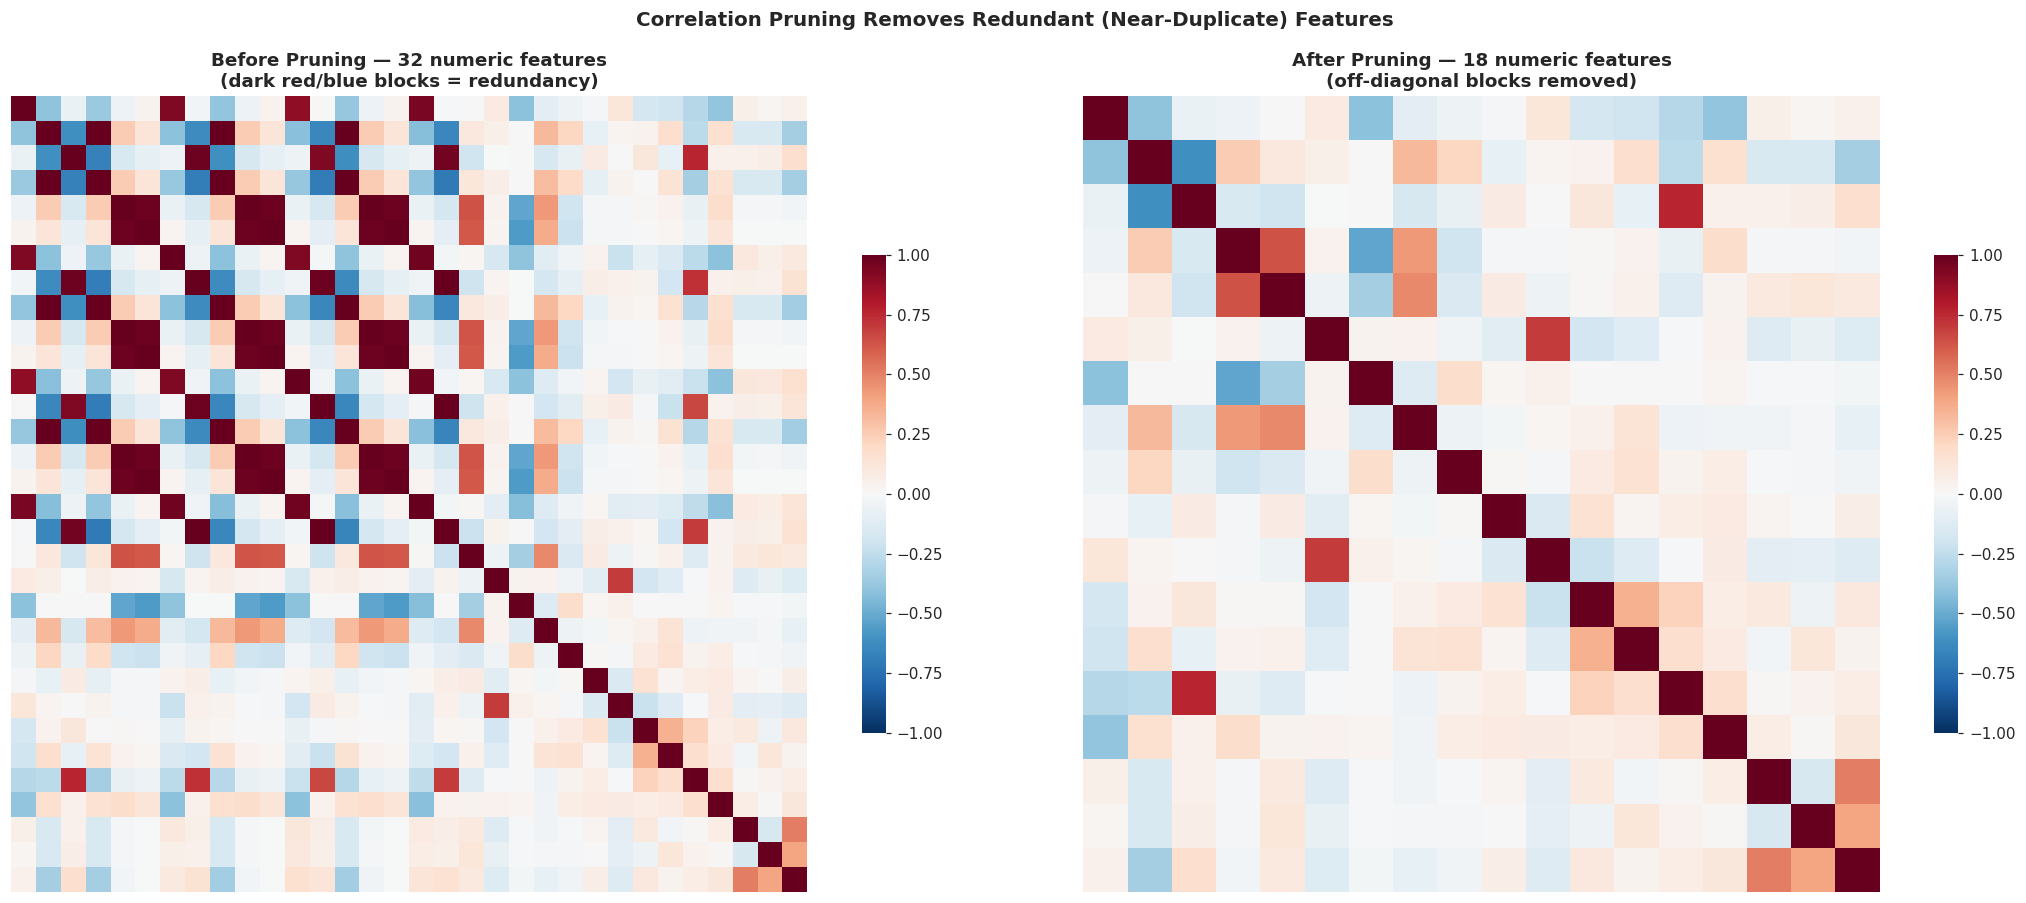

In [5]:
#CORRELATION PRUNING (|r| > 0.90)
CORR_THRESHOLD=0.90
numeric_feats=[c for c in feature_cols if c not in state_cols]
corr_abs=df_model[numeric_feats].corr().abs()
upper=corr_abs.where(np.triu(np.ones(corr_abs.shape),k=1).astype(bool))
to_drop=[col for col in upper.columns if any(upper[col]>CORR_THRESHOLD)]

#Record which survivor each dropped feature duplicated
drop_map={}
for col in to_drop:
    partner=upper[col][upper[col]>CORR_THRESHOLD].idxmax()
    drop_map[col]=(partner,round(upper.loc[partner,col],3) if not pd.isna(upper.loc[partner,col]) else round(upper[col].max(),3))

feature_cols_full=feature_cols.copy()              #keep the pre-prune list
feature_cols=[c for c in feature_cols if c not in to_drop]

#refresh variable groups to the pruned set
level_features=[c for c in level_features if c not in to_drop]
momentum_features=[c for c in momentum_features if c not in to_drop]

print(f'Dropped {len(to_drop)} redundant features (|r| > {CORR_THRESHOLD}):')
for col,(partner,r) in drop_map.items():
    print(f'  - {col:<32} ~ {partner} (r={r})')
print(f'\nFeature count: {len(feature_cols_full)} -> {len(feature_cols)}')

#Figure correlation matrix before vs after pruning
fig,(axL,axR)=plt.subplots(1,2,figsize=(20,8))
num_full=[c for c in feature_cols_full if c not in state_cols]
num_pruned=[c for c in feature_cols if c not in state_cols]
sns.heatmap(df_model[num_full].corr(),ax=axL,cmap='RdBu_r',center=0,vmin=-1,vmax=1,
            square=True,cbar_kws={'shrink':0.6},xticklabels=False)
axL.set_title(f'Before Pruning — {len(num_full)} numeric features\n(dark red/blue blocks = redundancy)',fontweight='bold')
axL.set_yticks([]);
sns.heatmap(df_model[num_pruned].corr(),ax=axR,cmap='RdBu_r',center=0,vmin=-1,vmax=1,
            square=True,cbar_kws={'shrink':0.6},xticklabels=False)
axR.set_title(f'After Pruning — {len(num_pruned)} numeric features\n(off-diagonal blocks removed)',fontweight='bold')
axR.set_yticks([])
fig.suptitle('Correlation Pruning Removes Redundant (Near-Duplicate) Features',fontweight='bold',fontsize=13,y=1.02)
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig_prune.png',dpi=150,bbox_inches='tight');plt.show()


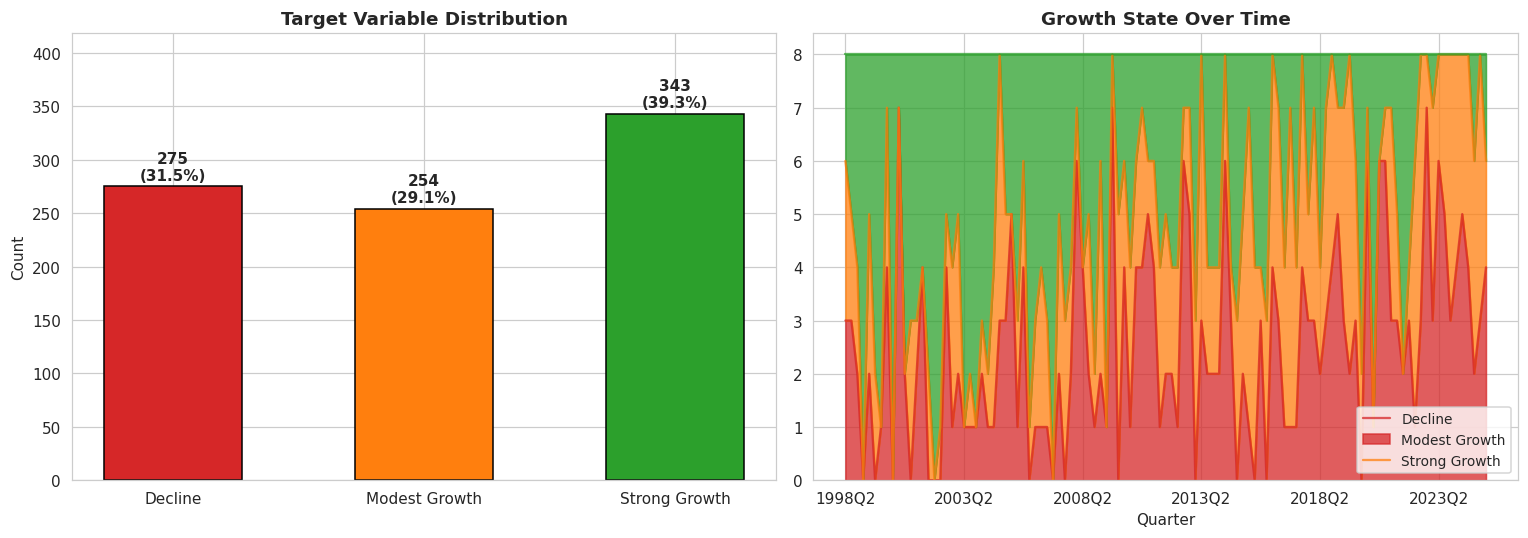

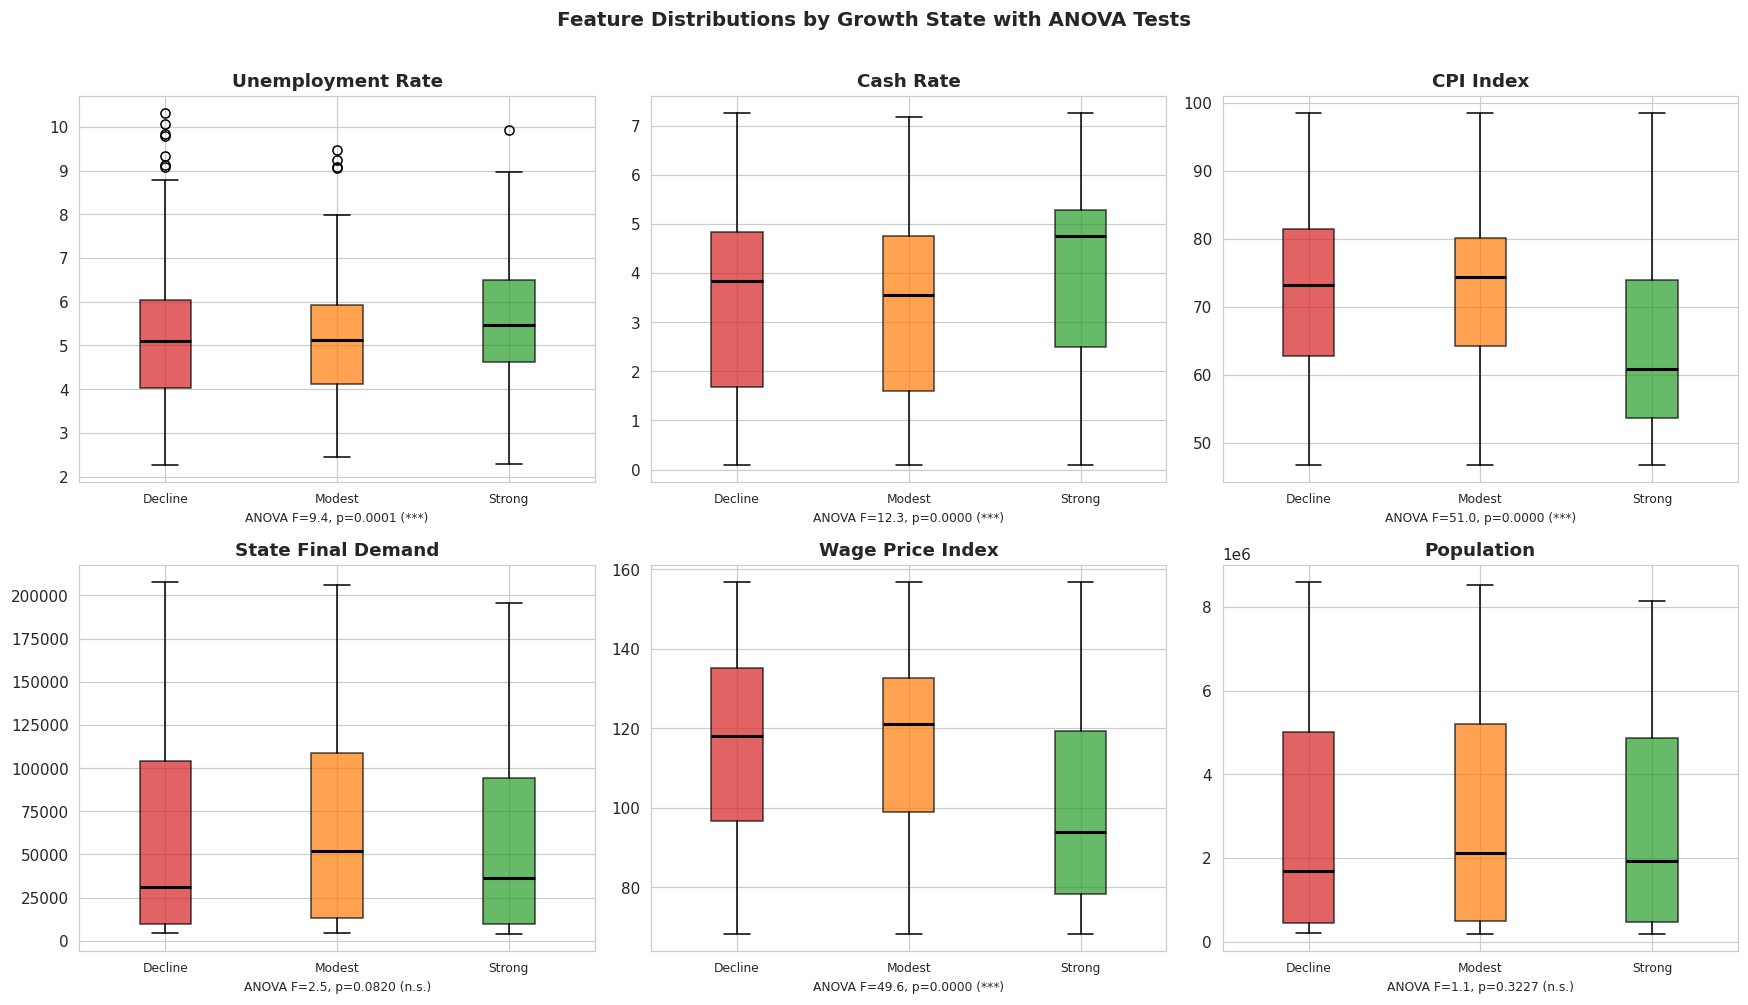

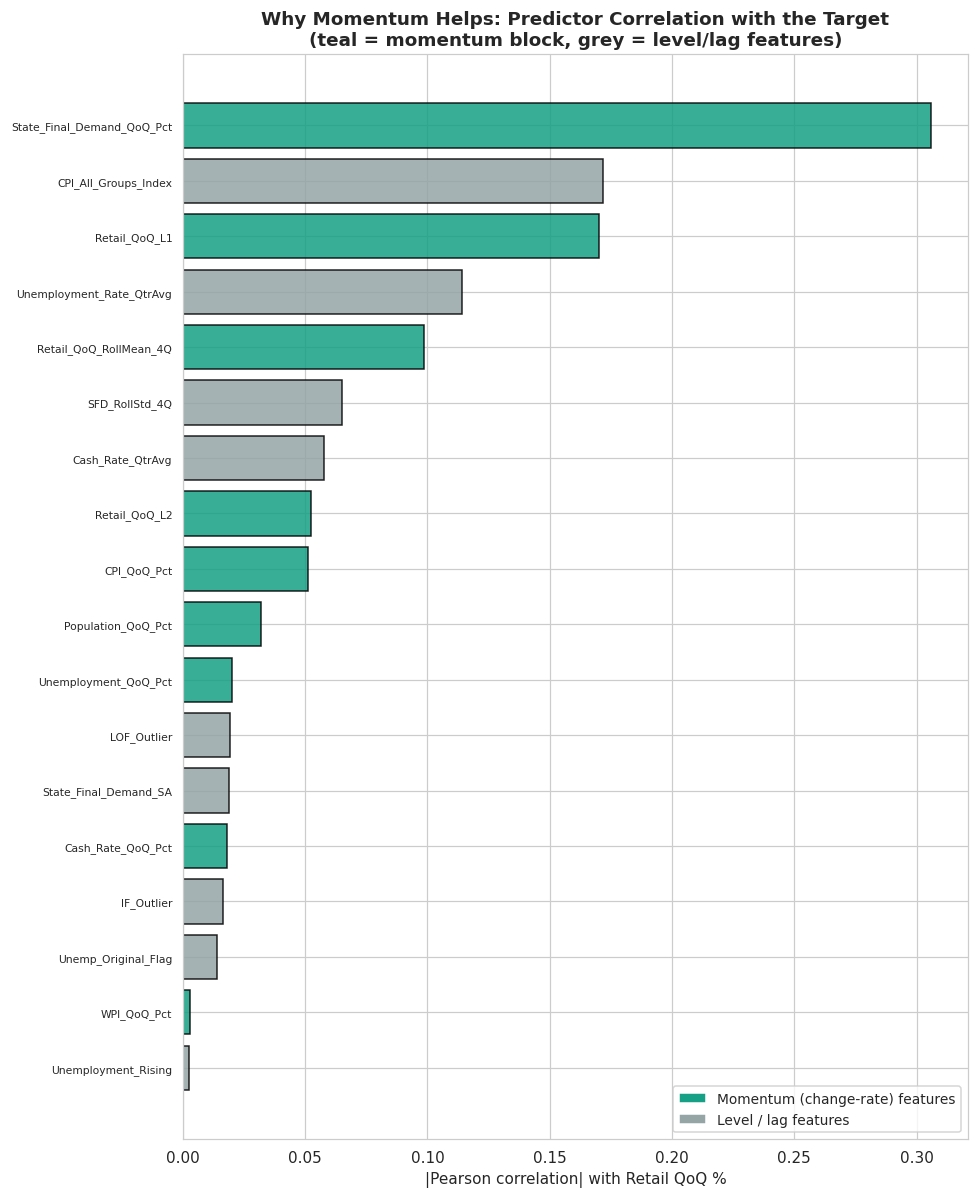

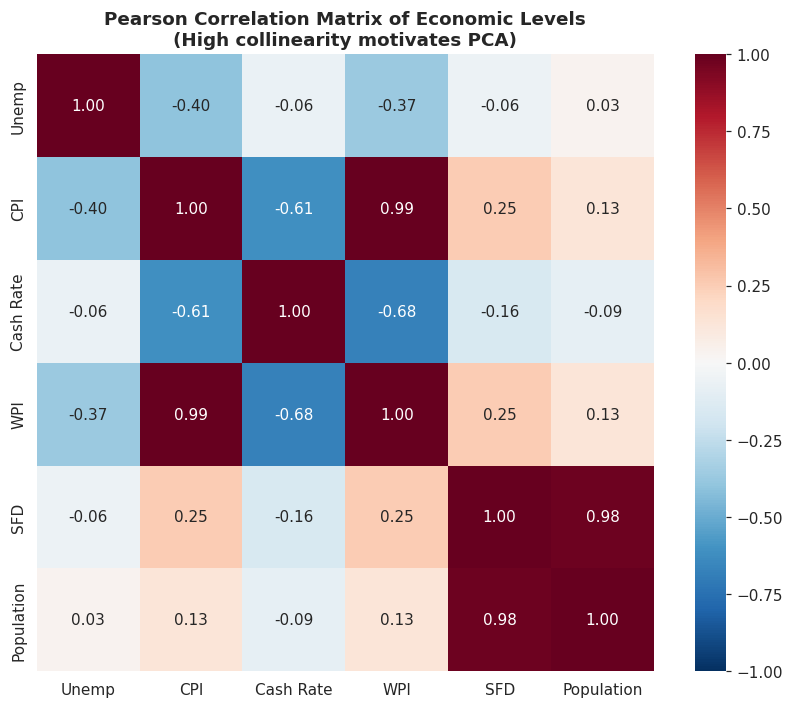

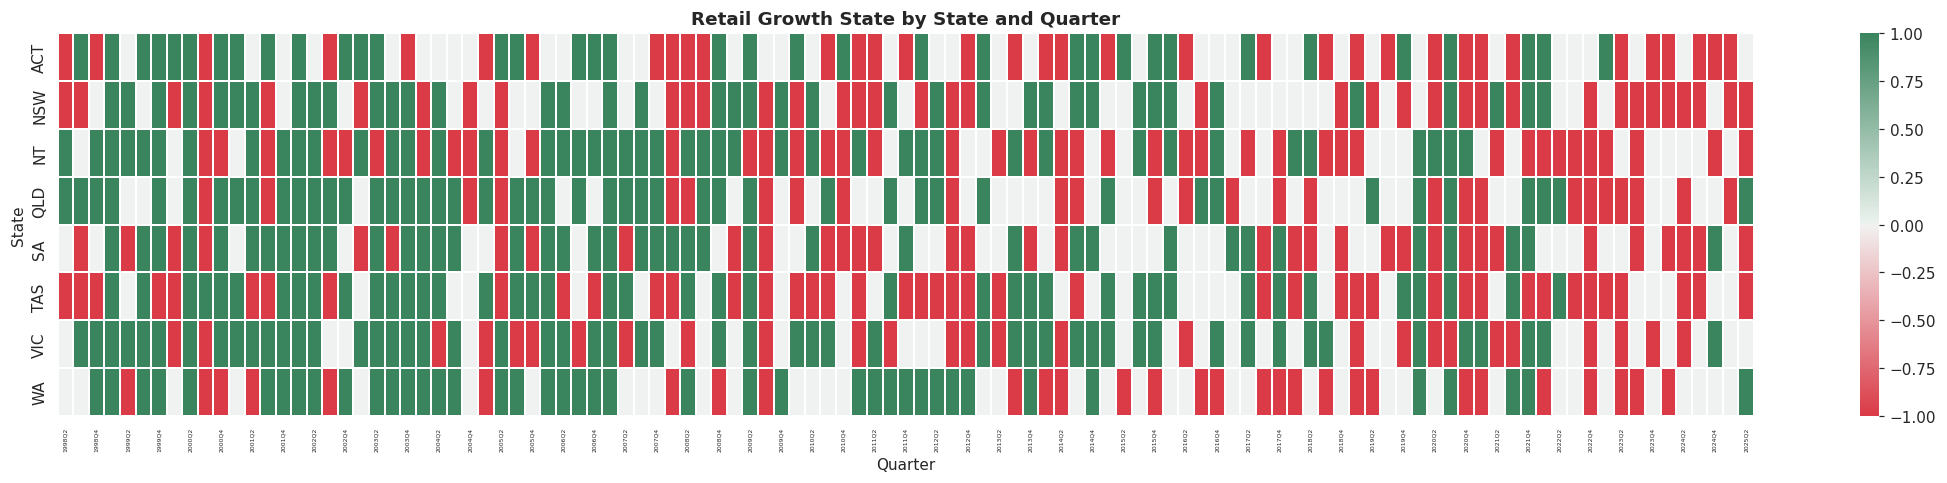

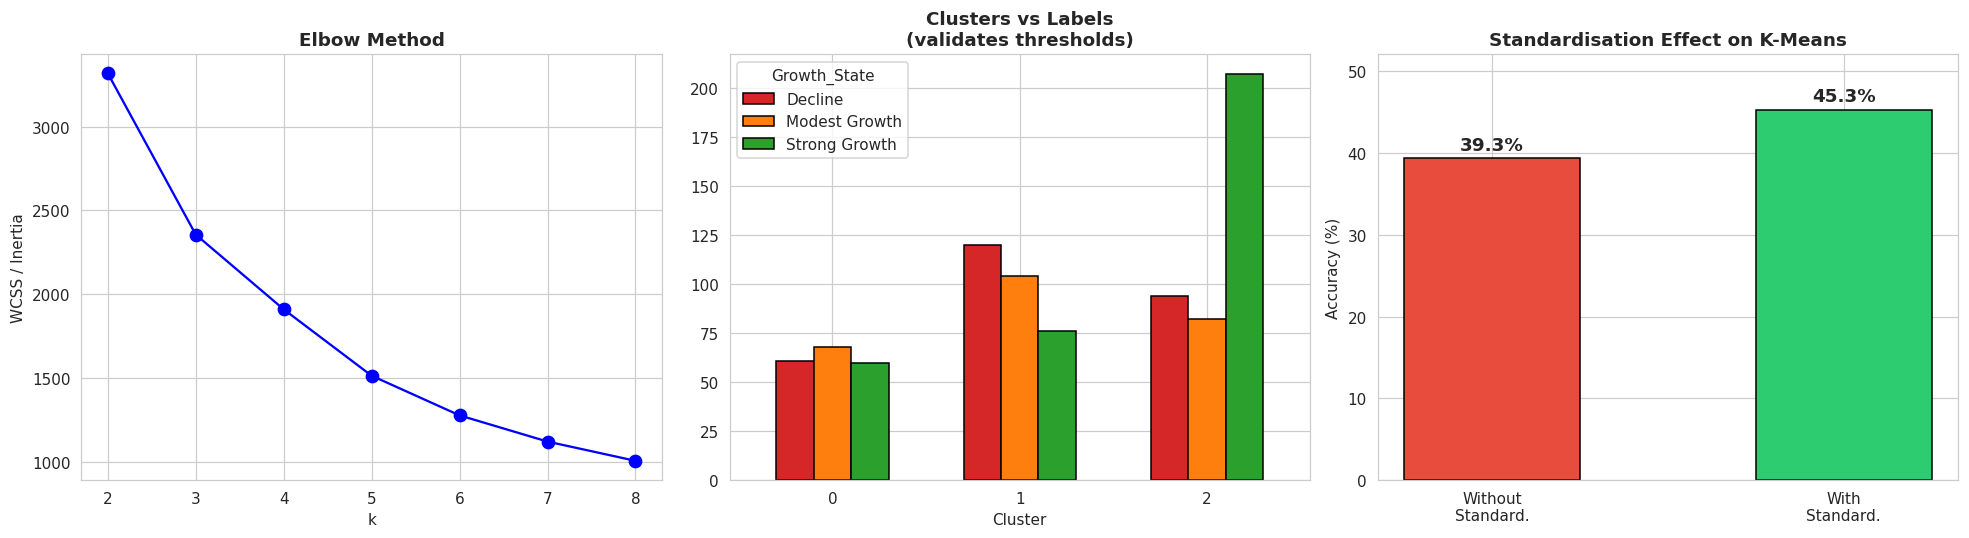

In [6]:
#EDA

#Fig 1: Class distribution + over time
fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5))
cts=df_model['Growth_State'].value_counts().reindex(CLASSES)
bars=a1.bar(CLASSES,cts.values,color=[CC[c] for c in CLASSES],edgecolor='black',width=0.55)
a1.set_title('Target Variable Distribution',fontweight='bold');a1.set_ylabel('Count');a1.set_ylim(0,cts.max()*1.22)
for b,v in zip(bars,cts.values):
    a1.text(b.get_x()+b.get_width()/2,v+6,f'{v}\n({v/len(df_model)*100:.1f}%)',ha='center',fontsize=10,fontweight='bold')
pvt=(df_model.groupby(['Quarter','Growth_State']).size().unstack(fill_value=0).reindex(columns=CLASSES,fill_value=0))
pvt.plot(kind='area',stacked=True,ax=a2,color=[CC[c] for c in CLASSES],alpha=0.75)
a2.set_title('Growth State Over Time',fontweight='bold');a2.legend(CLASSES,fontsize=9)
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig01.png',dpi=150,bbox_inches='tight');plt.show()

#Fig 2: Feature distributions by class + ANOVA
vf=['Unemployment_Rate_QtrAvg','Cash_Rate_QtrAvg','CPI_All_Groups_Index','State_Final_Demand_SA','WPI_Index_SA','Population']
vl=['Unemployment Rate','Cash Rate','CPI Index','State Final Demand','Wage Price Index','Population']
fig,axes=plt.subplots(2,3,figsize=(16,9))
for ax,ft,lb in zip(axes.flatten(),vf,vl):
    gs=[df_model.loc[df_model['Growth_State']==c,ft].dropna() for c in CLASSES]
    bp=ax.boxplot(gs,patch_artist=True,medianprops={'color':'black','linewidth':2})
    for p,cl in zip(bp['boxes'],CLASSES):p.set_facecolor(CC[cl]);p.set_alpha(0.72)
    ax.set_xticklabels(['Decline','Modest','Strong'],fontsize=8);ax.set_title(lb,fontweight='bold')
    fs,pv=stats.f_oneway(*gs);sig='***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
    ax.set_xlabel(f'ANOVA F={fs:.1f}, p={pv:.4f} ({sig})',fontsize=8)
fig.suptitle('Feature Distributions by Growth State with ANOVA Tests',fontweight='bold',fontsize=13,y=1.01)
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig02.png',dpi=150,bbox_inches='tight');plt.show()

#Fig 3: why momentum matters |correlation| of each predictor with the continuous target
corr_target=df_model[level_features+momentum_features].apply(
    lambda col: df_model['Retail_Turnover_QoQ_Pct'].corr(col)).abs().sort_values(ascending=True)
cols_c=['#16a085' if (f in momentum_features) else '#95a5a6' for f in corr_target.index]
fig,ax=plt.subplots(figsize=(9,11))
ax.barh(range(len(corr_target)),corr_target.values,color=cols_c,edgecolor='black',alpha=0.85)
ax.set_yticks(range(len(corr_target)));ax.set_yticklabels(corr_target.index,fontsize=7)
ax.set_xlabel('|Pearson correlation| with Retail QoQ %')
ax.set_title('Why Momentum Helps: Predictor Correlation with the Target\n'
             '(teal = momentum block, grey = level/lag features)',fontweight='bold')
ax.legend(handles=[Patch(facecolor='#16a085',label='Momentum (change-rate) features'),
                   Patch(facecolor='#95a5a6',label='Level / lag features')],fontsize=9,loc='lower right')
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig03.png',dpi=150,bbox_inches='tight');plt.show()

#Fig 4: Correlation matrix of the core economic levels
ct2=['Unemp','CPI','Cash Rate','WPI','SFD','Population']
cm=df_model[pca_vars].corr();cm.columns=ct2;cm.index=ct2
plt.figure(figsize=(8,6.5))
sns.heatmap(cm,annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,vmin=-1,vmax=1)
plt.title('Pearson Correlation Matrix of Economic Levels\n(High collinearity motivates PCA)',fontweight='bold')
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig04.png',dpi=150,bbox_inches='tight');plt.show()

#Fig 5: State x quarter growth heatmap
cn={'Decline':-1,'Modest Growth':0,'Strong Growth':1}
df_model['GN']=df_model['Growth_State'].map(cn)
pv2=df_model.pivot_table(index='State',columns='Quarter',values='GN',aggfunc='mean')
fig,ax=plt.subplots(figsize=(20,4.5))
sns.heatmap(pv2,cmap=sns.diverging_palette(10,145,as_cmap=True),center=0,ax=ax,linewidths=0.15)
ax.set_title('Retail Growth State by State and Quarter',fontweight='bold')
plt.xticks(rotation=90,fontsize=4);plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig05.png',dpi=150,bbox_inches='tight');plt.show()

#Fig 6: K-Means standardisation check (elbow + cluster vs label + standardisation effect)
class_map={'Decline':0,'Modest Growth':1,'Strong Growth':2}
y_num=df_model['Growth_State'].map(class_map).values
Xk_raw=df_model[pca_vars].fillna(0).values
Xk_std=StandardScaler().fit_transform(Xk_raw)
km_raw_acc=accuracy_score(y_num,map_cluster_to_class(KMeans(3,random_state=42,n_init=10).fit(Xk_raw).labels_,y_num,3))*100
km_std_acc=accuracy_score(y_num,map_cluster_to_class(KMeans(3,random_state=42,n_init=10).fit(Xk_std).labels_,y_num,3))*100
km_std=KMeans(n_clusters=3,random_state=42,n_init=10).fit(Xk_std)
iner=[KMeans(n_clusters=k,random_state=42,n_init=10).fit(Xk_std).inertia_ for k in range(2,9)]
fig,(a1,a2,a3)=plt.subplots(1,3,figsize=(18,5))
a1.plot(range(2,9),iner,'bo-',markersize=8);a1.set_xlabel('k');a1.set_ylabel('WCSS / Inertia')
a1.set_title('Elbow Method',fontweight='bold')
ct=pd.crosstab(km_std.labels_,df_model['Growth_State'])
ct.plot(kind='bar',ax=a2,color=[CC[c] for c in ct.columns],edgecolor='black',width=0.6)
a2.set_xlabel('Cluster');a2.set_title('Clusters vs Labels\n(validates thresholds)',fontweight='bold');a2.tick_params(axis='x',rotation=0)
bars3=a3.bar(['Without\nStandard.','With\nStandard.'],[km_raw_acc,km_std_acc],color=['#e74c3c','#2ecc71'],edgecolor='black',width=0.5)
a3.set_ylabel('Accuracy (%)');a3.set_title('Standardisation Effect on K-Means',fontweight='bold');a3.set_ylim(0,max(km_raw_acc,km_std_acc)*1.15)
for b,v in zip(bars3,[km_raw_acc,km_std_acc]):a3.text(b.get_x()+b.get_width()/2,v+1,f'{v:.1f}%',ha='center',fontsize=12,fontweight='bold')
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig06.png',dpi=150,bbox_inches='tight');plt.show()


In [7]:
#SPLIT + STANDARDISE + PCA
X=df_model[feature_cols].astype(float); y=df_model['Growth_State']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.10,random_state=42,stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)} (90/10 stratified split)')
scaler=StandardScaler(); X_train_sc=scaler.fit_transform(X_train); X_test_sc=scaler.transform(X_test)

#PCA uses the six economic levels sourced from df_model
Xtr_pca_src=df_model.loc[X_train.index, pca_vars]; Xte_pca_src=df_model.loc[X_test.index, pca_vars]
scaler_pca=StandardScaler()
Xp_tr=scaler_pca.fit_transform(Xtr_pca_src); Xp_te=scaler_pca.transform(Xte_pca_src)
pca_full=PCA(random_state=42).fit(Xp_tr)
ev_all=pca_full.explained_variance_ratio_; cum_all=ev_all.cumsum()
pca2=PCA(n_components=2,random_state=42).fit(Xp_tr)
Xpc_tr=pca2.transform(Xp_tr); Xpc_te=pca2.transform(Xp_te)
ev=pca2.explained_variance_ratio_
loadings=pd.DataFrame(pca2.components_.T,index=pca_labels,columns=['PC1','PC2'])
X_tr_pca=np.hstack([Xpc_tr,X_train[state_cols].values])
X_te_pca=np.hstack([Xpc_te,X_test[state_cols].values])
print(f'PC1={ev[0]*100:.1f}% PC2={ev[1]*100:.1f}% Total={sum(ev)*100:.1f}%')
print(loadings.round(3))


Train: 784 | Test: 88 (90/10 stratified split)
PC1=47.5% PC2=30.0% Total=77.5%
                      PC1    PC2
Unemployment       -0.216  0.193
CPI                 0.544 -0.238
Cash Rate          -0.413  0.190
WPI                 0.551 -0.241
State Final Demand  0.335  0.611
Population          0.268  0.663


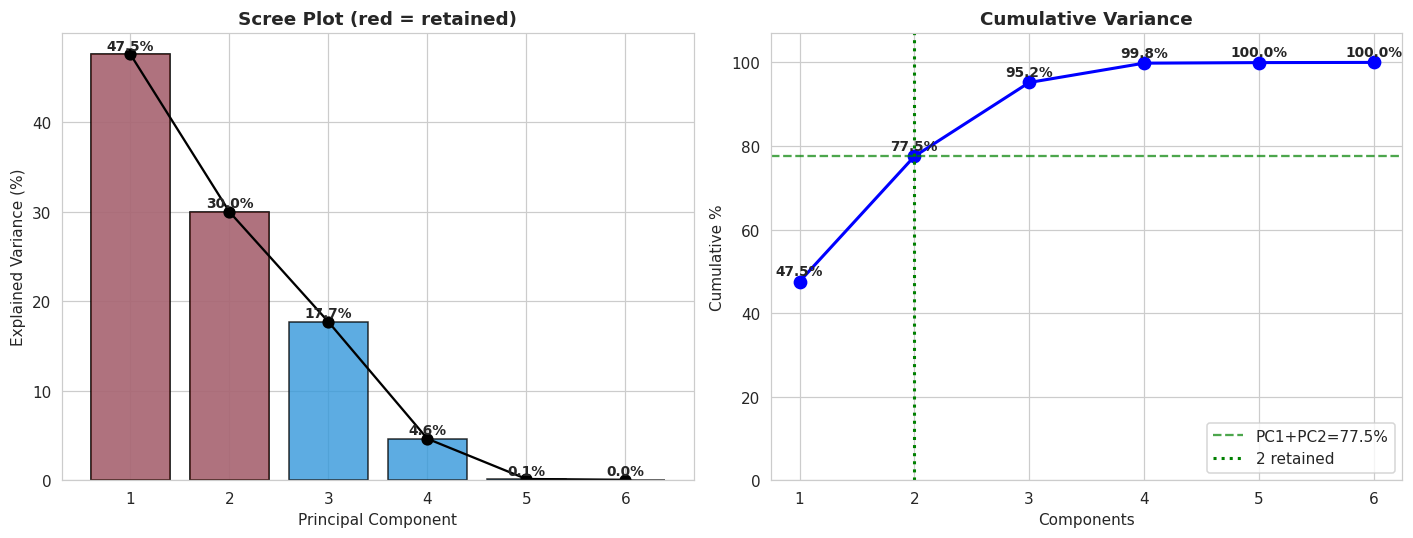

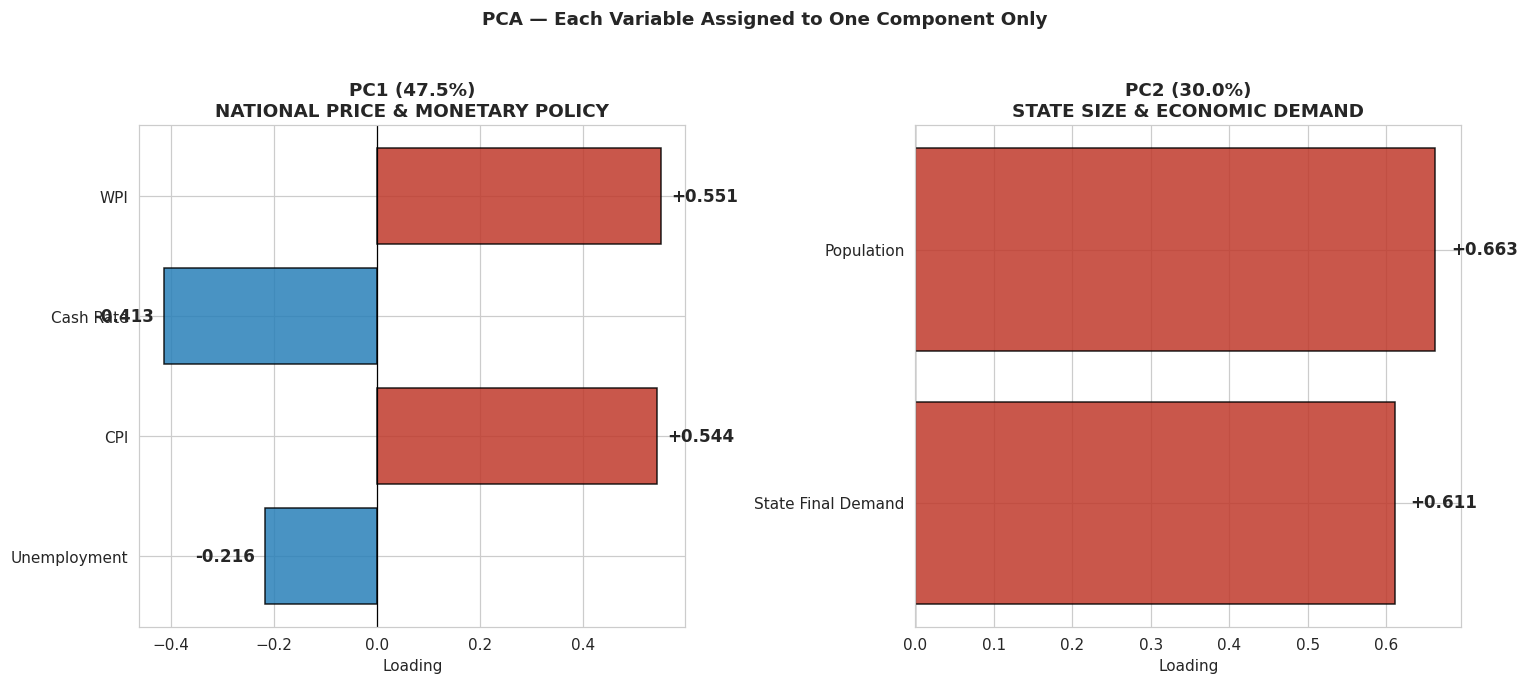

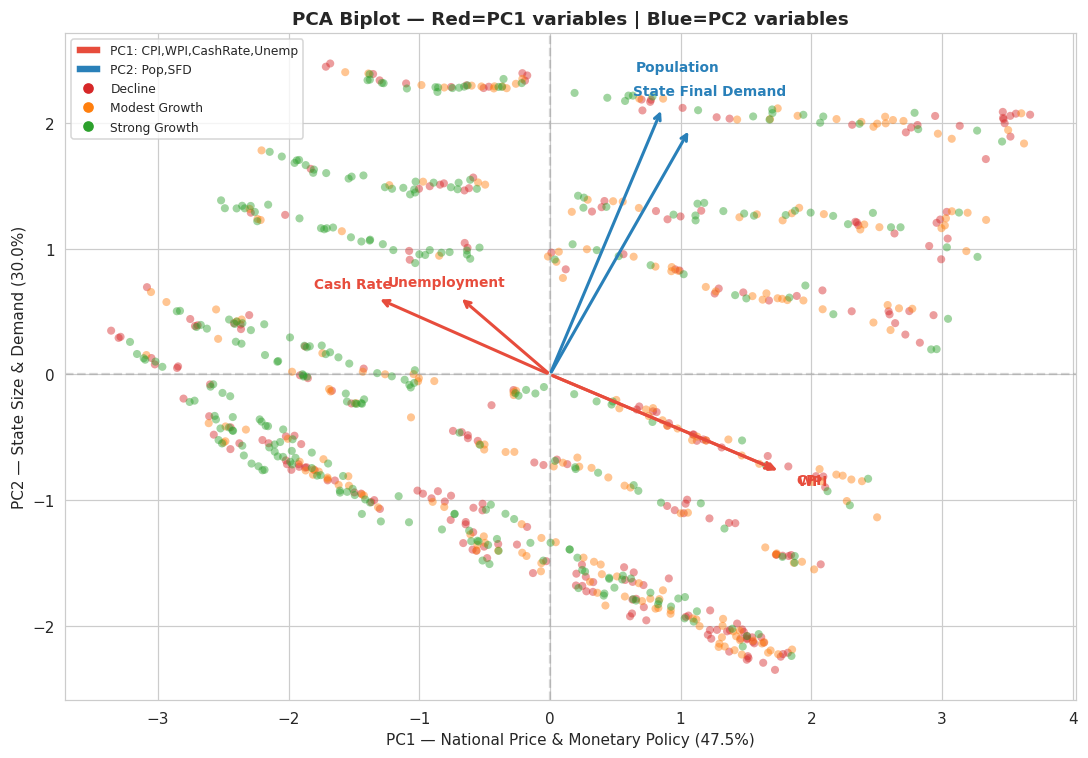

In [8]:
#PCA
pc1_vars=['Unemployment','CPI','Cash Rate','WPI']
pc2_vars=['State Final Demand','Population']
pc1_color='#e74c3c'; pc2_color='#2980b9'

#Fig 7: Scree + cumulative
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,5))
a1.bar(range(1,len(ev_all)+1),ev_all*100,color='#3498db',edgecolor='black',alpha=0.8)
a1.bar([1,2],[ev_all[0]*100,ev_all[1]*100],color='#e74c3c',edgecolor='black',alpha=0.6)
a1.plot(range(1,len(ev_all)+1),ev_all*100,'ko-',markersize=7)
a1.set_xlabel('Principal Component');a1.set_ylabel('Explained Variance (%)')
a1.set_title('Scree Plot (red = retained)',fontweight='bold')
for i,e in enumerate(ev_all):a1.text(i+1,e*100+0.5,f'{e*100:.1f}%',ha='center',fontsize=9,fontweight='bold')
a2.plot(range(1,len(cum_all)+1),cum_all*100,'bo-',markersize=8,linewidth=2)
a2.axhline(sum(ev)*100,color='green',ls='--',alpha=0.7,label=f'PC1+PC2={sum(ev)*100:.1f}%')
a2.axvline(2,color='green',ls=':',linewidth=2,label='2 retained')
a2.set_xlabel('Components');a2.set_ylabel('Cumulative %');a2.set_title('Cumulative Variance',fontweight='bold')
a2.set_ylim(0,107);a2.legend()
for i,c in enumerate(cum_all):a2.text(i+1,c*100+1.5,f'{c*100:.1f}%',ha='center',fontsize=9,fontweight='bold')
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig07.png',dpi=150,bbox_inches='tight');plt.show()

#Fig 8: PCA loadings split by component
fig,axes=plt.subplots(1,2,figsize=(14,6))
vals1=loadings.loc[pc1_vars,'PC1'].values
ax=axes[0];ax.barh(pc1_vars,vals1,color=['#c0392b' if v>0 else '#2980b9' for v in vals1],edgecolor='black',alpha=0.85)
ax.axvline(0,color='black',linewidth=0.8)
for i,v in enumerate(vals1):ax.text(v+(0.02 if v>=0 else -0.02),i,f'{v:+.3f}',va='center',ha=('left' if v>=0 else 'right'),fontsize=11,fontweight='bold')
ax.set_xlabel('Loading');ax.set_title(f'PC1 ({ev[0]*100:.1f}%)\nNATIONAL PRICE & MONETARY POLICY',fontweight='bold')
vals2=loadings.loc[pc2_vars,'PC2'].values
ax=axes[1];ax.barh(pc2_vars,vals2,color=['#c0392b' if v>0 else '#2980b9' for v in vals2],edgecolor='black',alpha=0.85)
ax.axvline(0,color='black',linewidth=0.8)
for i,v in enumerate(vals2):ax.text(v+(0.02 if v>=0 else -0.02),i,f'{v:+.3f}',va='center',ha=('left' if v>=0 else 'right'),fontsize=11,fontweight='bold')
ax.set_xlabel('Loading');ax.set_title(f'PC2 ({ev[1]*100:.1f}%)\nSTATE SIZE & ECONOMIC DEMAND',fontweight='bold')
fig.suptitle('PCA — Each Variable Assigned to One Component Only',fontweight='bold',fontsize=12,y=1.03)
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig08.png',dpi=150,bbox_inches='tight');plt.show()

#Fig 9: Biplot
fig,ax=plt.subplots(figsize=(10,7))
for cl in CLASSES:
    m=y_train.values==cl;ax.scatter(Xpc_tr[m,0],Xpc_tr[m,1],label=cl,alpha=0.45,s=28,color=CC[cl],edgecolors='none')
sc=3.2
for i,lbl in enumerate(pca_labels):
    acol=pc1_color if lbl in pc1_vars else pc2_color
    ax.annotate('',xy=(pca2.components_[0,i]*sc,pca2.components_[1,i]*sc),xytext=(0,0),arrowprops=dict(arrowstyle='->',color=acol,lw=2))
    ax.text(pca2.components_[0,i]*sc*1.14,pca2.components_[1,i]*sc*1.14,lbl,fontsize=9,fontweight='bold',ha='center',color=acol)
ax.axhline(0,color='grey',ls='--',alpha=0.3);ax.axvline(0,color='grey',ls='--',alpha=0.3)
ax.set_xlabel(f'PC1 — National Price & Monetary Policy ({ev[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 — State Size & Demand ({ev[1]*100:.1f}%)')
ax.set_title('PCA Biplot — Red=PC1 variables | Blue=PC2 variables',fontweight='bold')
ax.legend(handles=[Patch(facecolor=pc1_color,label='PC1: CPI,WPI,CashRate,Unemp'),Patch(facecolor=pc2_color,label='PC2: Pop,SFD'),
    *[plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=CC[c],markersize=8,label=c) for c in CLASSES]],fontsize=8,loc='upper left')
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig09.png',dpi=150,bbox_inches='tight');plt.show()


In [10]:
#BACKWARD ELIMINATION
#Uses statsmodels OLS p-values against the numeric class label as the elimination criterion.
import statsmodels.api as sm
y_num_be = df_model['Growth_State'].map({'Decline':-1,'Modest Growth':0,'Strong Growth':1}).values
X_be     = df_model[feature_cols].astype(float).copy()
remaining = list(X_be.columns)
ALPHA = 0.10
removed_be=[]
while True:
    Xc = sm.add_constant(X_be[remaining])
    res = sm.OLS(y_num_be, Xc).fit()
    pvals = res.pvalues.drop('const')
    if pvals.max() <= ALPHA: break
    worst = pvals.idxmax()
    removed_be.append((worst, round(pvals.max(),4)))
    remaining.remove(worst)
    if len(remaining)<=2: break
print(f'Backward elimination kept {len(remaining)}/{len(feature_cols)} features (alpha={ALPHA})')
print('Removed (in order):')
for n,p in removed_be[:15]:
    print(f'  - {n:<32} p={p}')
if len(removed_be)>15: print(f'  ... and {len(removed_be)-15} more')
print(f'\nSurvivors ({len(remaining)}):')
for r in remaining: print(f'  + {r}')

#main pipeline still uses feature_cols (correlation-pruned).
pd.Series(remaining, name='backward_elim_survivors').to_csv(f'{OUTPUT_DIR}/backward_elim_survivors.csv', index=False)


Backward elimination kept 13/25 features (alpha=0.1)
Removed (in order):
  - State_Final_Demand_SA            p=0.6896
  - IF_Outlier                       p=0.6493
  - Retail_QoQ_L1                    p=0.6173
  - Retail_QoQ_L2                    p=0.719
  - Unemployment_Rising              p=0.5367
  - Unemployment_Rate_QtrAvg         p=0.4924
  - State_NT                         p=0.5468
  - Cash_Rate_QoQ_Pct                p=0.3721
  - Unemployment_QoQ_Pct             p=0.296
  - SFD_RollStd_4Q                   p=0.1652
  - LOF_Outlier                      p=0.1752
  - Retail_QoQ_RollMean_4Q           p=0.1072

Survivors (13):
  + CPI_All_Groups_Index
  + Cash_Rate_QtrAvg
  + Unemp_Original_Flag
  + State_Final_Demand_QoQ_Pct
  + CPI_QoQ_Pct
  + WPI_QoQ_Pct
  + Population_QoQ_Pct
  + State_NSW
  + State_QLD
  + State_SA
  + State_TAS
  + State_VIC
  + State_WA


In [11]:
#CLASSIFIERS
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

#Majority-class baseline
dum_o=DummyClassifier(strategy='most_frequent', random_state=42).fit(X_train_sc, y_train)
dum_p=DummyClassifier(strategy='most_frequent', random_state=42).fit(X_tr_pca,    y_train)

#Naive Bayes
nb_o=GaussianNB().fit(X_train_sc,y_train)
nb_p=GaussianNB().fit(X_tr_pca,   y_train)

#Decision Tree
dt_grid={'max_depth':[3,5,7,10],'min_samples_split':[10,20,40],'min_samples_leaf':[5,10,20],
         'criterion':['gini','entropy']}
dt_o=GridSearchCV(DecisionTreeClassifier(random_state=42,class_weight='balanced'),
                  dt_grid,cv=skf,scoring='f1_macro',n_jobs=-1).fit(X_train_sc,y_train).best_estimator_
dt_p=GridSearchCV(DecisionTreeClassifier(random_state=42,class_weight='balanced'),
                  dt_grid,cv=skf,scoring='f1_macro',n_jobs=-1).fit(X_tr_pca,   y_train).best_estimator_

#Random Forest
rf_grid={'n_estimators':[300,500,800],'max_depth':[4,6,8,10],
         'min_samples_split':[10,20,30],'min_samples_leaf':[5,10,20],
         'max_features':['sqrt','log2']}
rf_o=GridSearchCV(RandomForestClassifier(random_state=42,class_weight='balanced'),
                  rf_grid,cv=skf,scoring='f1_macro',n_jobs=-1).fit(X_train_sc,y_train).best_estimator_
rf_p=GridSearchCV(RandomForestClassifier(random_state=42,class_weight='balanced'),
                  rf_grid,cv=skf,scoring='f1_macro',n_jobs=-1).fit(X_tr_pca,   y_train).best_estimator_

#Support Vector Machine
svm_grid={'C':[0.5,1,5,10,50],'kernel':['rbf','linear'],
          'gamma':['scale','auto']}
svm_o=GridSearchCV(SVC(probability=True,random_state=42,class_weight='balanced'),
                   svm_grid,cv=skf,scoring='f1_macro',n_jobs=-1).fit(X_train_sc,y_train).best_estimator_
svm_p=GridSearchCV(SVC(probability=True,random_state=42,class_weight='balanced'),
                   svm_grid,cv=skf,scoring='f1_macro',n_jobs=-1).fit(X_tr_pca,   y_train).best_estimator_

#Linear SVM pipeline
svm_linear_pipe=make_pipeline(StandardScaler(),SVC(kernel='linear',class_weight='balanced'))
svm_linear_pipe.fit(X_train,y_train)

print(f'DT : depth={dt_o.max_depth}  min_leaf={dt_o.min_samples_leaf}  crit={dt_o.criterion}')
print(f'RF : depth={rf_o.max_depth}  min_leaf={rf_o.min_samples_leaf}  n={rf_o.n_estimators}  feat={rf_o.max_features}')
print(f'SVM: C={svm_o.C}  kernel={svm_o.kernel}  gamma={svm_o.gamma}')


DT : depth=5  min_leaf=5  crit=entropy
RF : depth=10  min_leaf=5  n=800  feat=sqrt
SVM: C=1  kernel=linear  gamma=scale


Computing repeated 10-fold CV (10 reps x 10 folds = 100 estimates per model)...
  Dummy-Orig   done
  Dummy-PCA    done
  NB-Orig      done
  NB-PCA       done
  DT-Orig      done
  DT-PCA       done
  RF-Orig      done
  RF-PCA       done
  SVM-Orig     done
  SVM-PCA      done

OVERFITTING + RELIABILITY TABLE
--------------------------------------------------------------------------------------------
Model          Train    Test   CV-mean   CV-std      CV 95% band     Gap
--------------------------------------------------------------------------------------------
Dummy-Orig     0.188   0.186     0.188    0.001   [0.185, 0.190]  +0.003
Dummy-PCA      0.188   0.186     0.188    0.001   [0.185, 0.190]  +0.003
NB-Orig        0.439   0.432     0.395    0.051   [0.309, 0.508]  +0.008
NB-PCA         0.405   0.430     0.363    0.051   [0.264, 0.455]  -0.024
DT-Orig        0.569   0.444     0.458    0.059   [0.355, 0.587]  +0.125
DT-PCA         0.470   0.403     0.402    0.053   [0.298, 0.485

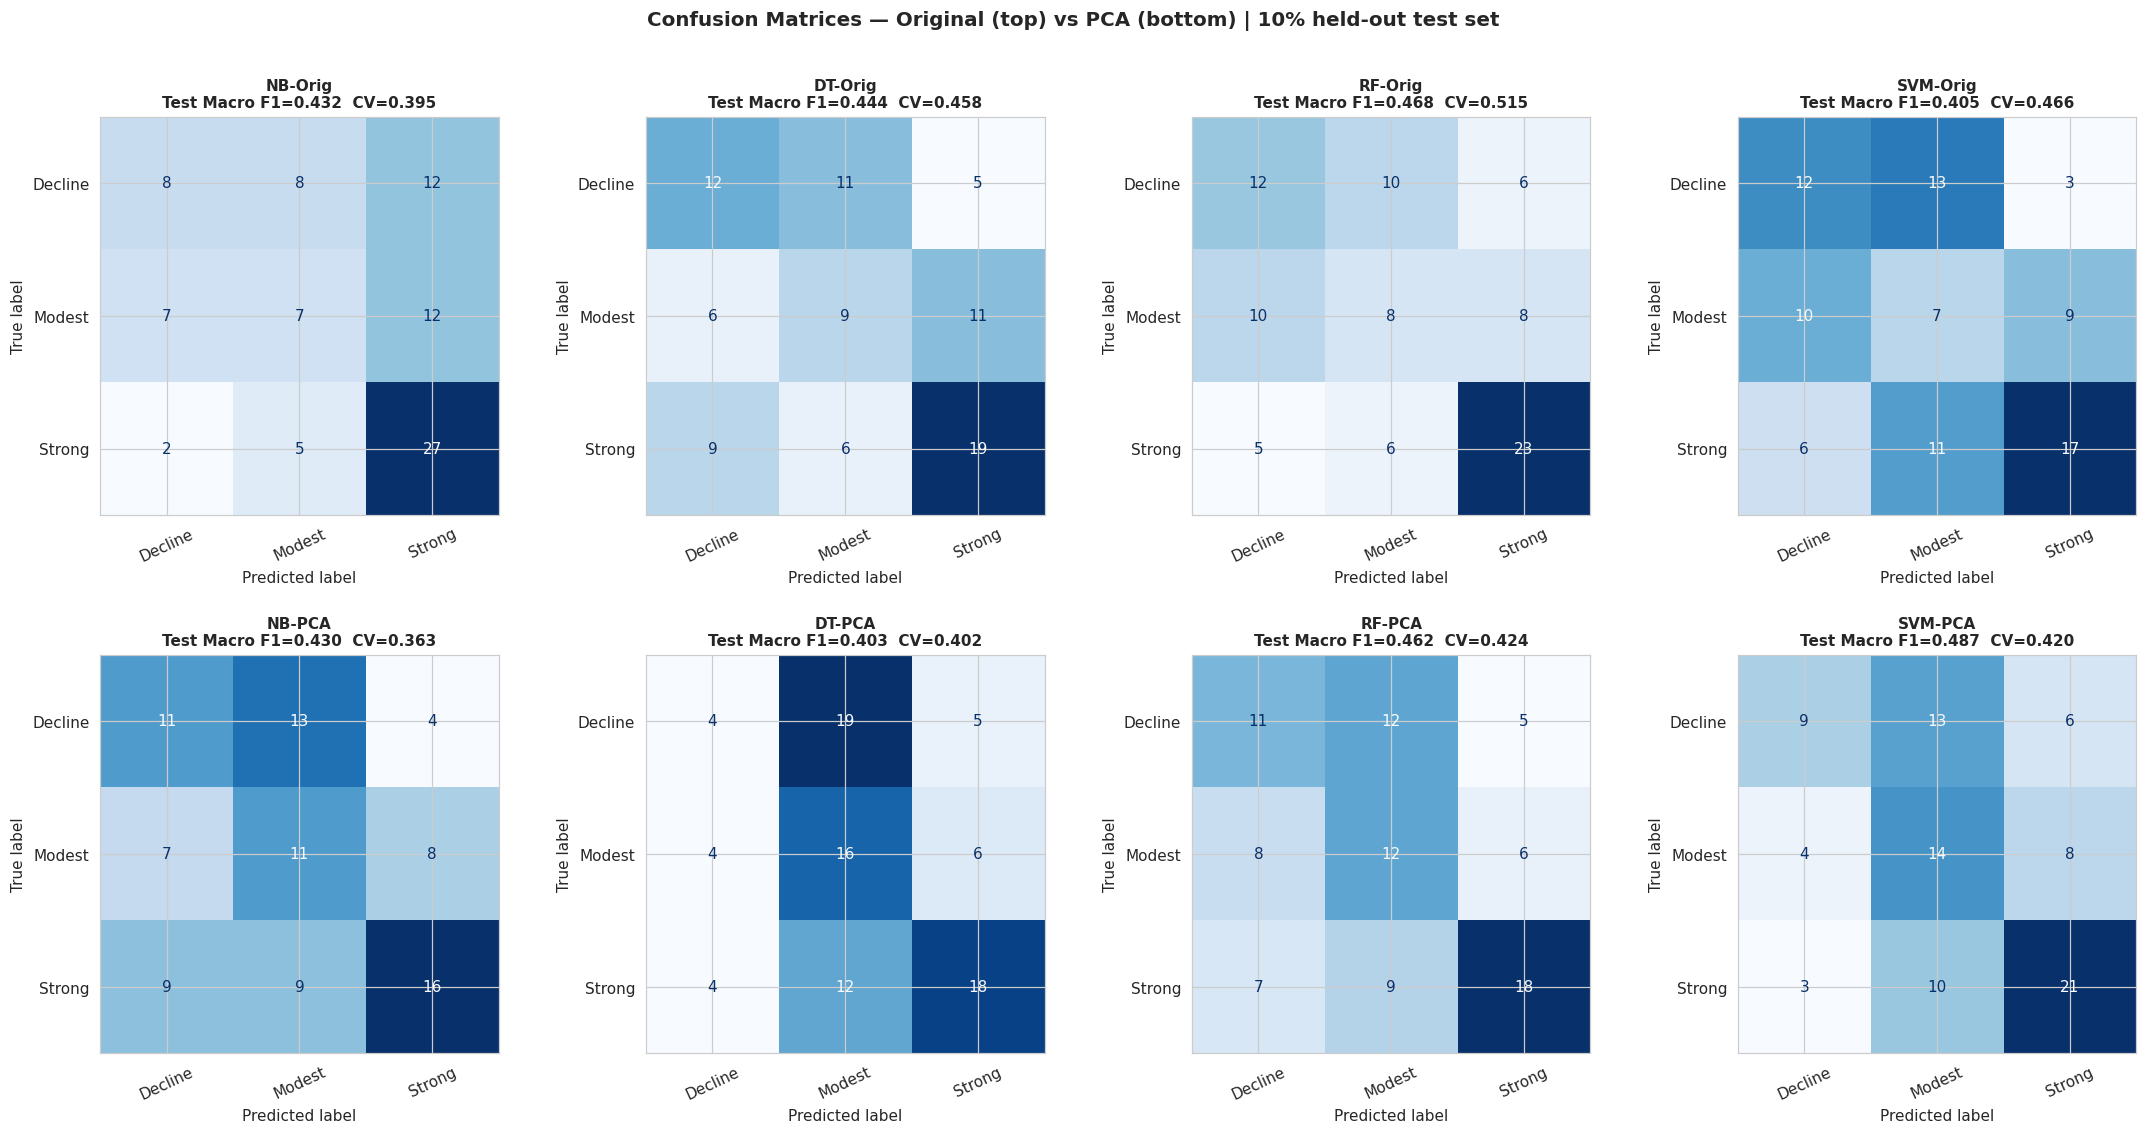

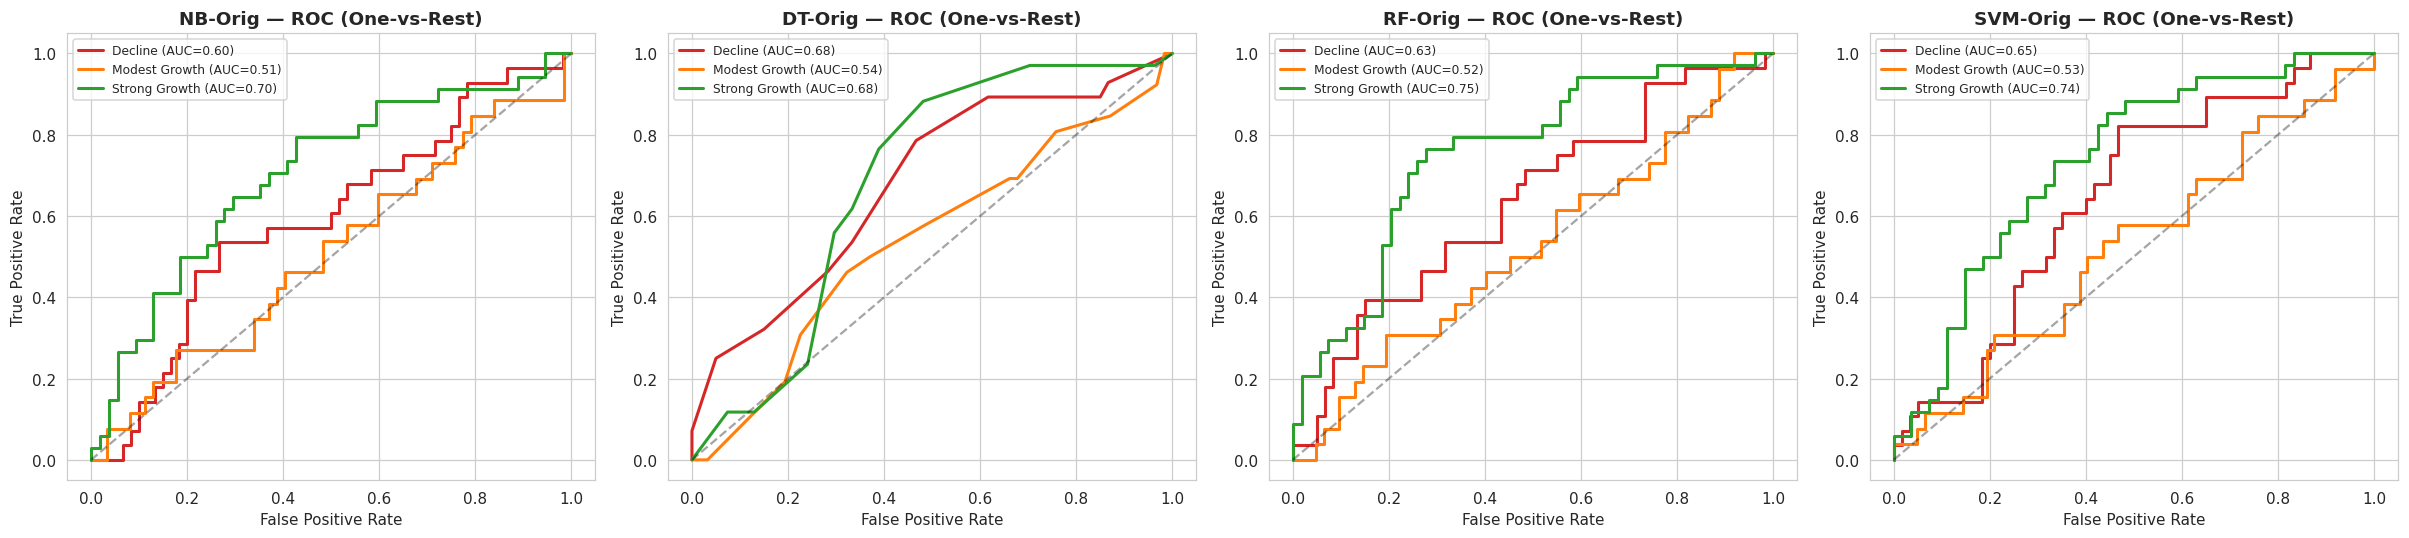

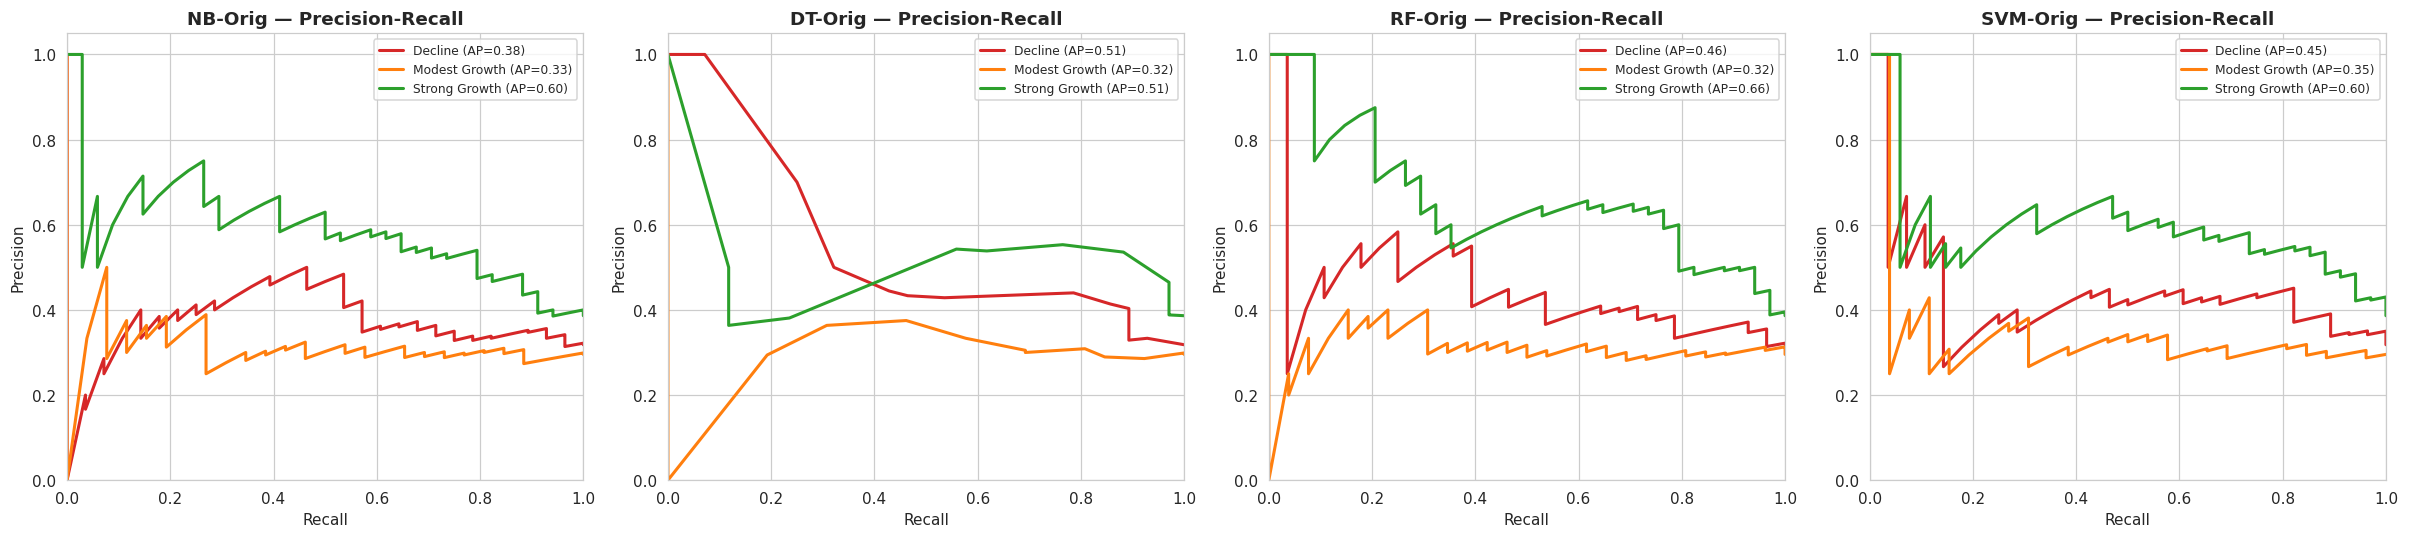

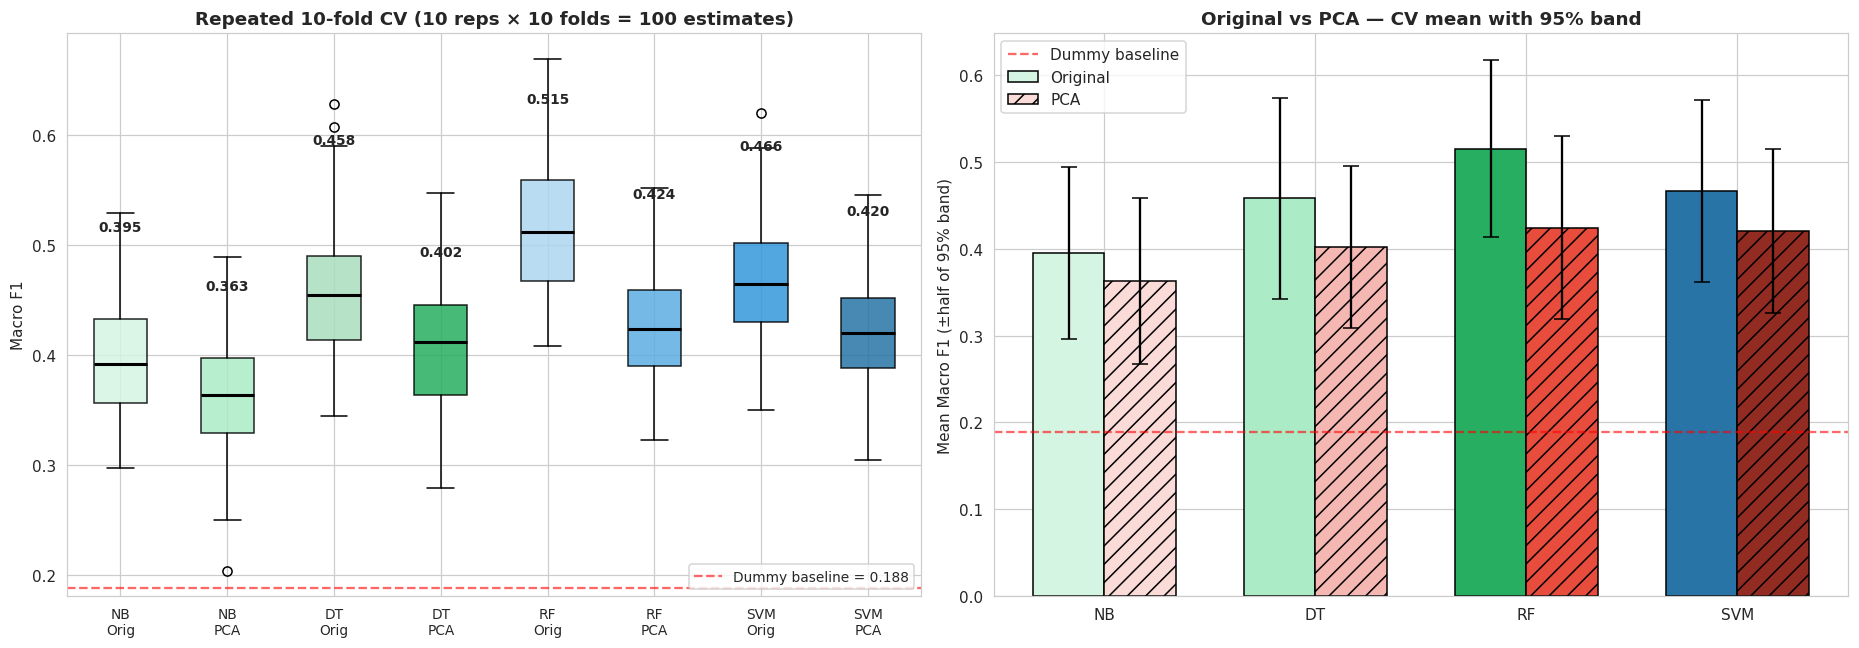

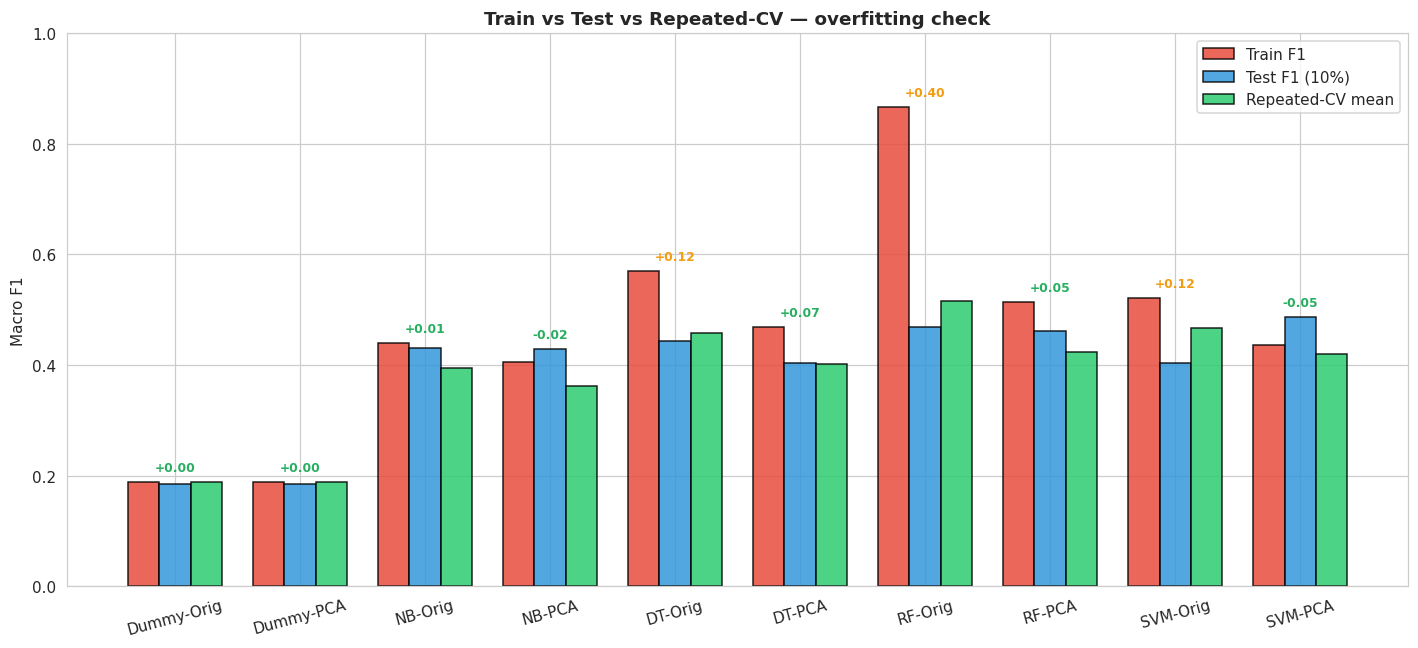

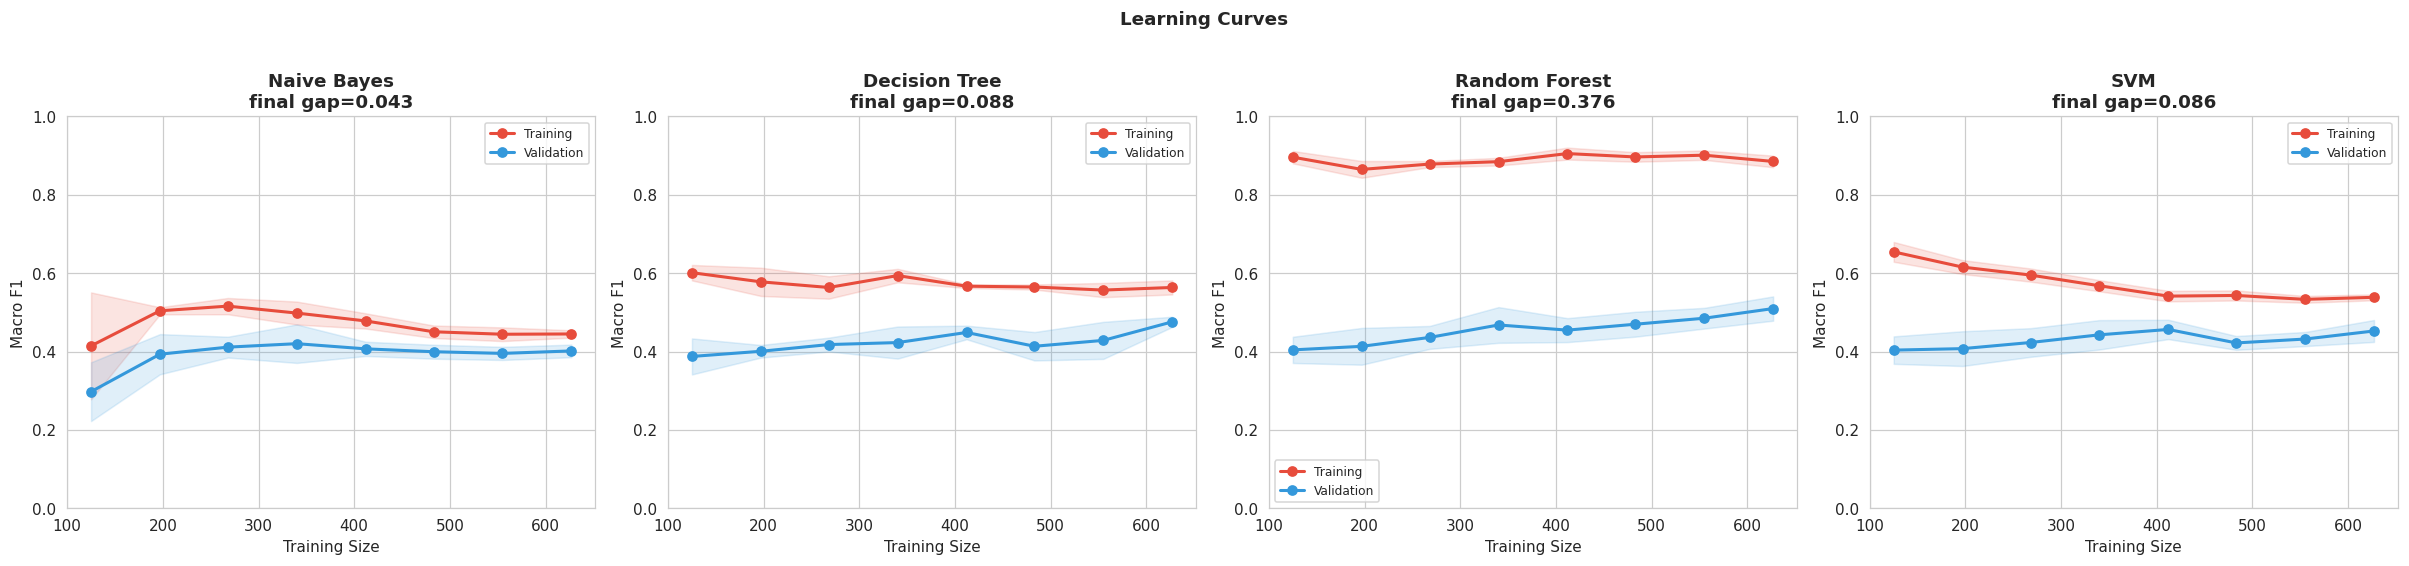

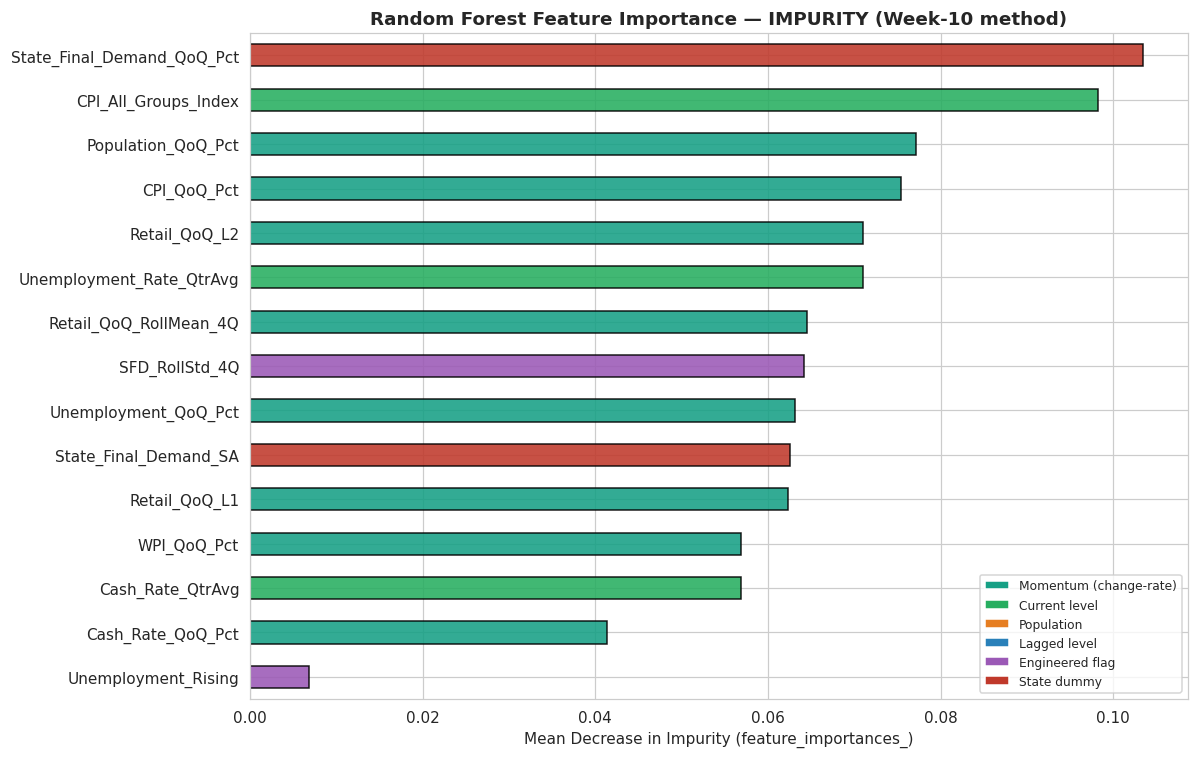


All evaluation outputs saved to /content/drive/MyDrive/PRT564_Project_Final Assessment/outputs_a4_final


In [12]:
#EVALUATION
all_m={'Dummy-Orig':(dum_o,X_train_sc,X_test_sc),'Dummy-PCA':(dum_p,X_tr_pca,X_te_pca),
       'NB-Orig'   :(nb_o, X_train_sc,X_test_sc),'NB-PCA'   :(nb_p, X_tr_pca,X_te_pca),
       'DT-Orig'   :(dt_o, X_train_sc,X_test_sc),'DT-PCA'   :(dt_p, X_tr_pca,X_te_pca),
       'RF-Orig'   :(rf_o, X_train_sc,X_test_sc),'RF-PCA'   :(rf_p, X_tr_pca,X_te_pca),
       'SVM-Orig'  :(svm_o,X_train_sc,X_test_sc),'SVM-PCA'  :(svm_p,X_tr_pca,X_te_pca)}

results=[]
print('Computing repeated 10-fold CV (10 reps x 10 folds = 100 estimates per model)...')
for name,(mdl,Xtr,Xte) in all_m.items():
    yp = mdl.predict(Xte)

    try:
        ypr = mdl.predict_proba(Xte)
        yb  = label_binarize(y_test, classes=list(mdl.classes_))
        roc = roc_auc_score(yb, ypr, average='macro', multi_class='ovr')
    except Exception:
        ypr, roc = None, np.nan

    #Repeated CV
    rep = repeated_cv_f1(mdl, Xtr, y_train, n_folds=10, n_reps=10, seed_base=42)
    summ = cv_summary(rep)

    tr_f1 = f1_score(y_train, mdl.predict(Xtr), average='macro', zero_division=0)
    te_f1 = f1_score(y_test,  yp,                 average='macro', zero_division=0)

    results.append({
        'name':name,'model':mdl,'y_pred':yp,'y_prob':ypr,
        'cv_all':rep,
        'cv_mean':summ['mean'],'cv_std':summ['std'],'cv_lo':summ['lo'],'cv_hi':summ['hi'],
        'train_f1':tr_f1,'test_f1':te_f1,'gap':tr_f1-te_f1,
        'acc':accuracy_score(y_test,yp),
        'prec':precision_score(y_test,yp,average='macro',zero_division=0),
        'rec' :recall_score(y_test,yp,average='macro',zero_division=0),
        'roc':roc
    })
    print(f'  {name:<12} done')

print()
print('OVERFITTING + RELIABILITY TABLE')
print('-'*92)
print(f'{"Model":<12} {"Train":>7} {"Test":>7} {"CV-mean":>9} {"CV-std":>8} {"CV 95% band":>16} {"Gap":>7}')
print('-'*92)
for r in results:
    band=f'[{r["cv_lo"]:.3f}, {r["cv_hi"]:.3f}]'
    print(f'{r["name"]:<12} {r["train_f1"]:>7.3f} {r["test_f1"]:>7.3f} {r["cv_mean"]:>9.3f} {r["cv_std"]:>8.3f} {band:>16} {r["gap"]:>+7.3f}')

dummy_cv = next(r for r in results if r['name']=='Dummy-Orig')['cv_mean']
print(f'\nMajority-class baseline (Dummy-Orig) CV macro-F1 = {dummy_cv:.3f}  <- every real model must beat this')

best_cv   = max(results, key=lambda r:r['cv_mean'])
best_test = max(results, key=lambda r:r['test_f1'])
print(f'\nBest by repeated-CV mean: {best_cv["name"]}  cv={best_cv["cv_mean"]:.3f} [{best_cv["cv_lo"]:.3f}, {best_cv["cv_hi"]:.3f}]  test={best_cv["test_f1"]:.3f}')
print(f'Best by single test F1  : {best_test["name"]}  test={best_test["test_f1"]:.3f}  cv={best_test["cv_mean"]:.3f}')
print('\nWe select the final model on REPEATED-CV mean (more reliable than the small 10% test set).')
best=best_cv
print('\nClassification report for the selected model on the 10% held-out test set:')
print(classification_report(y_test, best['y_pred'], target_names=CLASSES, zero_division=0))

#Plot order
plot_order=['NB-Orig','DT-Orig','RF-Orig','SVM-Orig','NB-PCA','DT-PCA','RF-PCA','SVM-PCA']

#Fig 10: Confusion matrices
fig,axes=plt.subplots(2,4,figsize=(20,10))
for ax,name in zip(axes.flatten(), plot_order):
    r=[x for x in results if x['name']==name][0]
    cm2=confusion_matrix(y_test, r['y_pred'], labels=CLASSES)
    ConfusionMatrixDisplay(cm2, display_labels=['Decline','Modest','Strong']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nTest Macro F1={r["test_f1"]:.3f}  CV={r["cv_mean"]:.3f}', fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', rotation=25)
fig.suptitle('Confusion Matrices — Original (top) vs PCA (bottom) | 10% held-out test set', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout(h_pad=3); plt.savefig(f'{OUTPUT_DIR}/fig10.png', dpi=150, bbox_inches='tight'); plt.show()

#Fig 11: ROC curves
fig,axes=plt.subplots(1,4,figsize=(22,5))
yb=label_binarize(y_test,classes=CLASSES); clc=['#d62728','#ff7f0e','#2ca02c']
for ax,name in zip(axes,['NB-Orig','DT-Orig','RF-Orig','SVM-Orig']):
    r=[x for x in results if x['name']==name][0]; mcl=list(r['model'].classes_)
    for i,cl in enumerate(CLASSES):
        ci=mcl.index(cl); fpr,tpr,_=roc_curve(yb[:,i], r['y_prob'][:,ci])
        ax.plot(fpr,tpr,linewidth=2,color=clc[i],label=f'{cl} (AUC={auc(fpr,tpr):.2f})')
    ax.plot([0,1],[0,1],'k--',alpha=0.35); ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name} — ROC (One-vs-Rest)', fontweight='bold'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/fig11.png', dpi=150, bbox_inches='tight'); plt.show()

#Fig 12: Precision-Recall curves
fig,axes=plt.subplots(1,4,figsize=(22,5))
for ax,name in zip(axes,['NB-Orig','DT-Orig','RF-Orig','SVM-Orig']):
    r=[x for x in results if x['name']==name][0]; mcl=list(r['model'].classes_)
    for i,cl in enumerate(CLASSES):
        ci=mcl.index(cl); pr,rc,_=precision_recall_curve(yb[:,i], r['y_prob'][:,ci])
        ap=average_precision_score(yb[:,i], r['y_prob'][:,ci])
        ax.plot(rc,pr,linewidth=2,color=clc[i],label=f'{cl} (AP={ap:.2f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{name} — Precision-Recall', fontweight='bold'); ax.legend(fontsize=8); ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/fig12.png', dpi=150, bbox_inches='tight'); plt.show()

#Fig 13: Repeated-CV comparison
fig,(a1,a2)=plt.subplots(1,2,figsize=(17,6))
ordered=[r for r in results if r['name'] in plot_order]
labels13=[r['name'] for r in ordered]
all_cv =[r['cv_all'] for r in ordered]
bp=a1.boxplot(all_cv, patch_artist=True, medianprops={'color':'black','linewidth':2})
cvc=['#d5f5e3','#abebc6','#a9dfbf','#27ae60','#aed6f1','#5dade2','#3498db','#2874a6']
for p,col in zip(bp['boxes'], cvc): p.set_facecolor(col); p.set_alpha(0.85)
a1.set_xticklabels([n.replace('-','\n') for n in labels13], fontsize=9)
a1.set_ylabel('Macro F1'); a1.set_title('Repeated 10-fold CV (10 reps × 10 folds = 100 estimates)', fontweight='bold')
a1.axhline(dummy_cv, color='red', ls='--', alpha=0.6, label=f'Dummy baseline = {dummy_cv:.3f}')
a1.legend(loc='lower right', fontsize=9)
for i,r in enumerate(ordered): a1.text(i+1, r['cv_hi']+0.005, f'{r["cv_mean"]:.3f}', ha='center', fontsize=9, fontweight='bold')

#Original vs PCA mean +- 95% band
families=['NB','DT','RF','SVM']
x=np.arange(len(families)); w=0.34
om=[next(r for r in results if r['name']==f+'-Orig')['cv_mean'] for f in families]
oe=[(next(r for r in results if r['name']==f+'-Orig')['cv_hi'] -
     next(r for r in results if r['name']==f+'-Orig')['cv_lo'])/2 for f in families]
pm=[next(r for r in results if r['name']==f+'-PCA')['cv_mean'] for f in families]
pe=[(next(r for r in results if r['name']==f+'-PCA')['cv_hi'] -
     next(r for r in results if r['name']==f+'-PCA')['cv_lo'])/2 for f in families]
a2.bar(x-w/2, om, w, yerr=oe, capsize=5, label='Original', color=['#d5f5e3','#abebc6','#27ae60','#2874a6'], edgecolor='black')
a2.bar(x+w/2, pm, w, yerr=pe, capsize=5, label='PCA',      color=['#fadbd8','#f5b7b1','#e74c3c','#922b21'], edgecolor='black', hatch='//')
a2.axhline(dummy_cv, color='red', ls='--', alpha=0.6, label=f'Dummy baseline')
a2.set_xticks(x); a2.set_xticklabels(families); a2.set_ylabel('Mean Macro F1 (±half of 95% band)')
a2.legend(); a2.set_title('Original vs PCA — CV mean with 95% band', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/fig13.png', dpi=150, bbox_inches='tight'); plt.show()

#Fig 14: Overfitting diagnostic
fig,ax=plt.subplots(figsize=(13,6))
names=[r['name'] for r in results]; xp=np.arange(len(names)); w2=0.25
ax.bar(xp-w2,[r['train_f1'] for r in results],w2,label='Train F1',color='#e74c3c',alpha=0.85,edgecolor='black')
ax.bar(xp,   [r['test_f1']  for r in results],w2,label='Test F1 (10%)',color='#3498db',alpha=0.85,edgecolor='black')
ax.bar(xp+w2,[r['cv_mean']  for r in results],w2,label='Repeated-CV mean',color='#2ecc71',alpha=0.85,edgecolor='black')
ax.set_xticks(xp); ax.set_xticklabels(names, rotation=15); ax.set_ylabel('Macro F1'); ax.legend()
ax.set_title('Train vs Test vs Repeated-CV — overfitting check', fontweight='bold')
for i,r in enumerate(results):
    c='#27ae60' if r['gap']<0.10 else '#f39c12'
    ax.text(i, max(r['train_f1'],r['test_f1'])+0.02, f'{r["gap"]:+.2f}', ha='center', fontsize=8, fontweight='bold', color=c)
ax.set_ylim(0,1.0); plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/fig14.png', dpi=150, bbox_inches='tight'); plt.show()

#Fig 15: Learning curves (four real models on the Original feature space)
fig,axes=plt.subplots(1,4,figsize=(22,5))
for ax,(nm,mdl,Xt) in zip(axes,[('Naive Bayes',nb_o,X_train_sc),('Decision Tree',dt_o,X_train_sc),
                                ('Random Forest',rf_o,X_train_sc),('SVM',svm_o,X_train_sc)]):
    tsz,trsc,tesc=learning_curve(mdl,Xt,y_train,cv=skf,scoring='f1_macro',
                                 train_sizes=np.linspace(0.2,1.0,8),n_jobs=-1,random_state=42)
    trm,tem=trsc.mean(axis=1),tesc.mean(axis=1)
    ax.fill_between(tsz,trsc.mean(1)-trsc.std(1),trsc.mean(1)+trsc.std(1),alpha=0.15,color='#e74c3c')
    ax.fill_between(tsz,tesc.mean(1)-tesc.std(1),tesc.mean(1)+tesc.std(1),alpha=0.15,color='#3498db')
    ax.plot(tsz,trm,'o-',color='#e74c3c',linewidth=2,label='Training')
    ax.plot(tsz,tem,'o-',color='#3498db',linewidth=2,label='Validation')
    ax.set_xlabel('Training Size'); ax.set_ylabel('Macro F1')
    ax.set_title(f'{nm}\nfinal gap={trm[-1]-tem[-1]:.3f}', fontweight='bold'); ax.legend(fontsize=8); ax.set_ylim(0,1.0)
fig.suptitle('Learning Curves', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/fig15.png', dpi=150, bbox_inches='tight'); plt.show()

#Fig 16: Feature importance — RF IMPURITY only
rf_fi=pd.Series(rf_o.feature_importances_, index=feature_cols).nlargest(15)
fig,ax=plt.subplots(figsize=(11,7))
rf_fi.iloc[::-1].plot(kind='barh', ax=ax, color=[fc(n) for n in rf_fi.index[::-1]], edgecolor='black', alpha=0.88)
ax.set_xlabel('Mean Decrease in Impurity (feature_importances_)')
ax.set_title('Random Forest Feature Importance — IMPURITY (Week-10 method)', fontweight='bold')
ax.legend(handles=[Patch(facecolor='#16a085',label='Momentum (change-rate)'),
                   Patch(facecolor='#27ae60',label='Current level'),
                   Patch(facecolor='#e67e22',label='Population'),
                   Patch(facecolor='#2980b9',label='Lagged level'),
                   Patch(facecolor='#9b59b6',label='Engineered flag'),
                   Patch(facecolor='#c0392b',label='State dummy')],
          fontsize=8, loc='lower right')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/fig16.png', dpi=150, bbox_inches='tight'); plt.show()

#Save summary table
summary=pd.DataFrame([{'Model':r['name'],'Train F1':r['train_f1'],'Test F1':r['test_f1'],
    'Gap':round(r['gap'],4),
    'CV mean':round(r['cv_mean'],4),'CV std':round(r['cv_std'],4),
    'CV 2.5%':round(r['cv_lo'],4),'CV 97.5%':round(r['cv_hi'],4),
    'Acc':round(r['acc'],4),'Prec':round(r['prec'],4),'Rec':round(r['rec'],4),
    'ROC-AUC':(round(r['roc'],4) if not np.isnan(r['roc']) else 'N/A')} for r in results])
summary.to_excel(f'{OUTPUT_DIR}/model_summary.xlsx', index=False)
df_model.to_csv(f'{OUTPUT_DIR}/classification_panel.csv', index=False)
print(f'\nAll evaluation outputs saved to {OUTPUT_DIR}')


Levels only            n=872  RF Test F1=0.440  RF 10-fold CV F1=0.443
Momentum only          n=872  RF Test F1=0.407  RF 10-fold CV F1=0.496
Levels + Momentum      n=872  RF Test F1=0.468  RF 10-fold CV F1=0.504


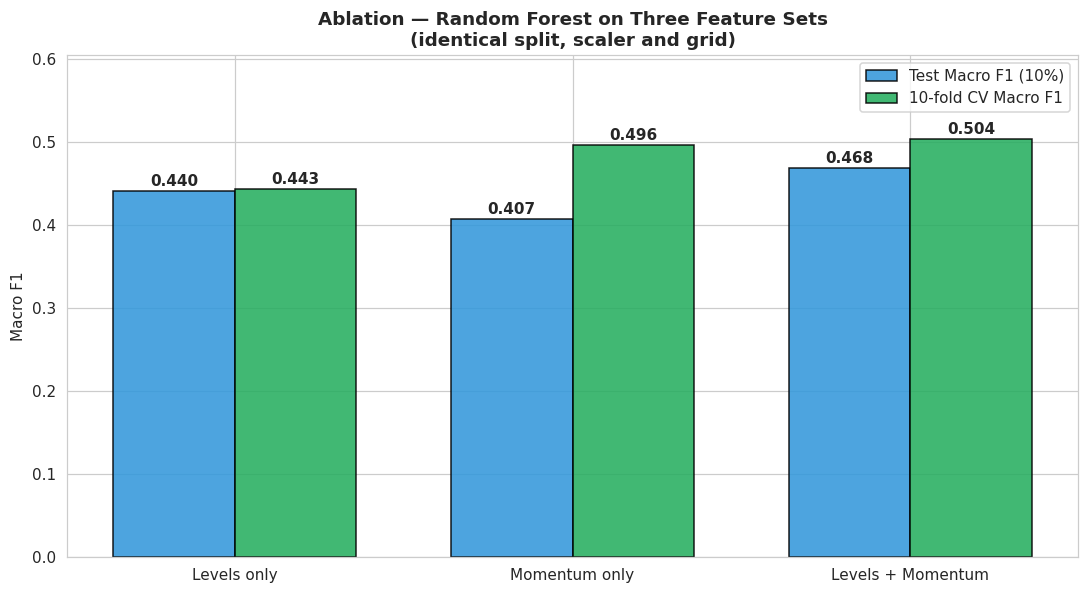

In [13]:
#ABLATION: LEVELS vs MOMENTUM vs BOTH
ablation_sets={
    'Levels only':        level_features+state_cols,
    'Momentum only':      momentum_features+state_cols,
    'Levels + Momentum':  level_features+momentum_features+state_cols,
}
abl_rows=[]
for tag,fcols in ablation_sets.items():
    dm=df.dropna(subset=fcols+['Growth_State']).reset_index(drop=True)
    Xa=dm[fcols].astype(float); ya=dm['Growth_State']
    Xatr,Xate,yatr,yate=train_test_split(Xa,ya,test_size=0.10,random_state=42,stratify=ya)
    sca=StandardScaler(); Xatr_s=sca.fit_transform(Xatr); Xate_s=sca.transform(Xate)
    rf_a=GridSearchCV(RandomForestClassifier(random_state=42,class_weight='balanced'),
        rf_grid,cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42),
        scoring='f1_macro',n_jobs=-1).fit(Xatr_s,yatr).best_estimator_
    te=f1_score(yate,rf_a.predict(Xate_s),average='macro',zero_division=0)
    cvm=cross_val_score(rf_a,Xatr_s,yatr,cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=42),
                        scoring='f1_macro',n_jobs=-1).mean()
    abl_rows.append({'Feature set':tag,'n rows':len(dm),'Test F1':te,'CV F1':cvm})
    print(f'{tag:<22} n={len(dm)}  RF Test F1={te:.3f}  RF 10-fold CV F1={cvm:.3f}')

abl=pd.DataFrame(abl_rows)
fig,ax=plt.subplots(figsize=(10,5.5))
xa=np.arange(len(abl)); wa=0.36
b1=ax.bar(xa-wa/2,abl['Test F1'],wa,label='Test Macro F1 (10%)',color='#3498db',edgecolor='black',alpha=0.88)
b2=ax.bar(xa+wa/2,abl['CV F1'],  wa,label='10-fold CV Macro F1', color='#27ae60',edgecolor='black',alpha=0.88)
ax.set_xticks(xa); ax.set_xticklabels(abl['Feature set'])
ax.set_ylabel('Macro F1'); ax.set_ylim(0, max(abl[['Test F1','CV F1']].values.max()*1.2, 0.6))
ax.set_title('Ablation — Random Forest on Three Feature Sets\n(identical split, scaler and grid)', fontweight='bold')
ax.legend()
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.006, f'{b.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/fig17.png', dpi=150, bbox_inches='tight'); plt.show()
abl.round(4).to_excel(f'{OUTPUT_DIR}/ablation_momentum.xlsx', index=False)


--- Baseline (mean) ---  MAE=1.157  MSE=2.178  RMSE=1.476
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best RF Regressor params: {'max_depth': 10, 'n_estimators': 1000}
--- RF Regressor ---  MAE=1.010  MSE=1.689  RMSE=1.300
--- Linear Regression ---  MAE=1.136  MSE=2.152  RMSE=1.467


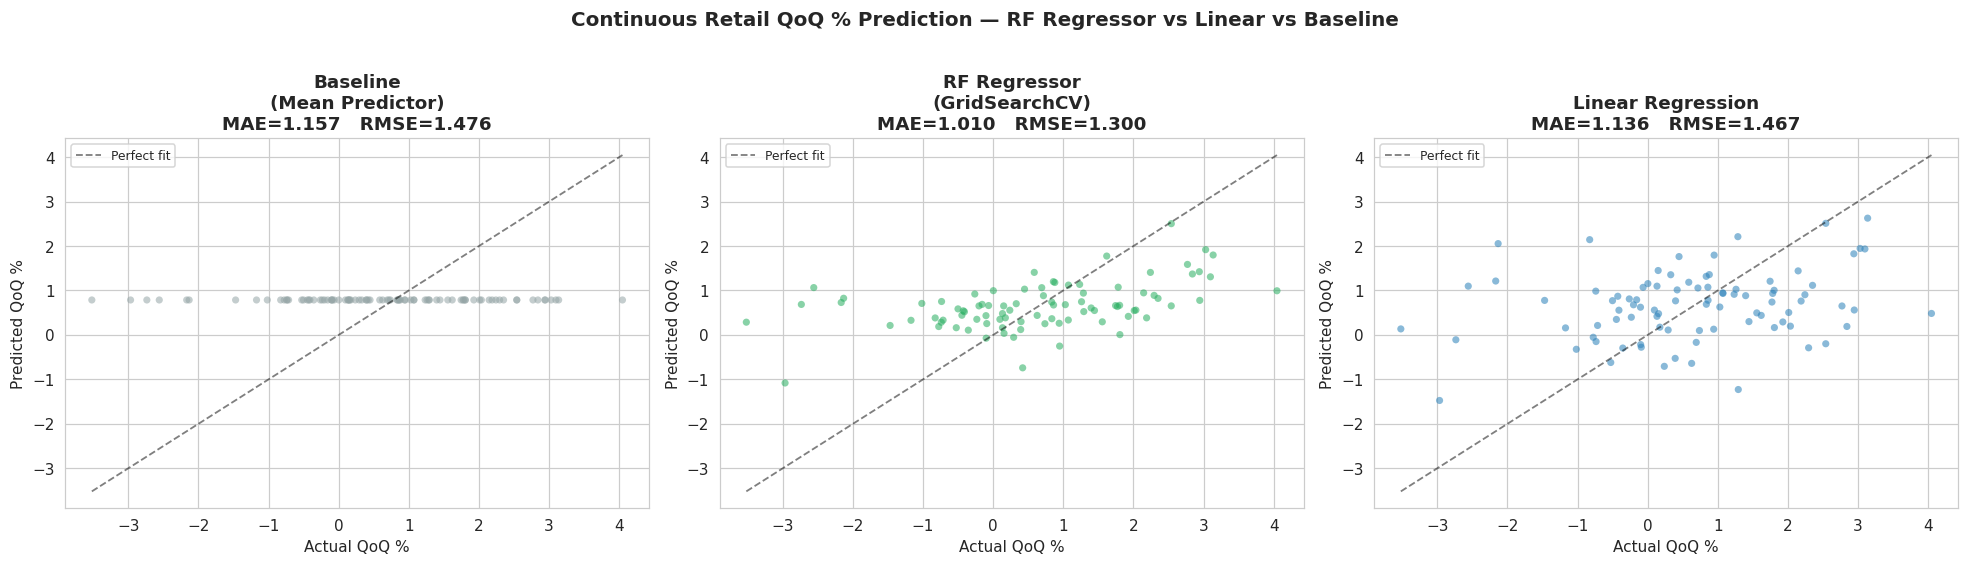

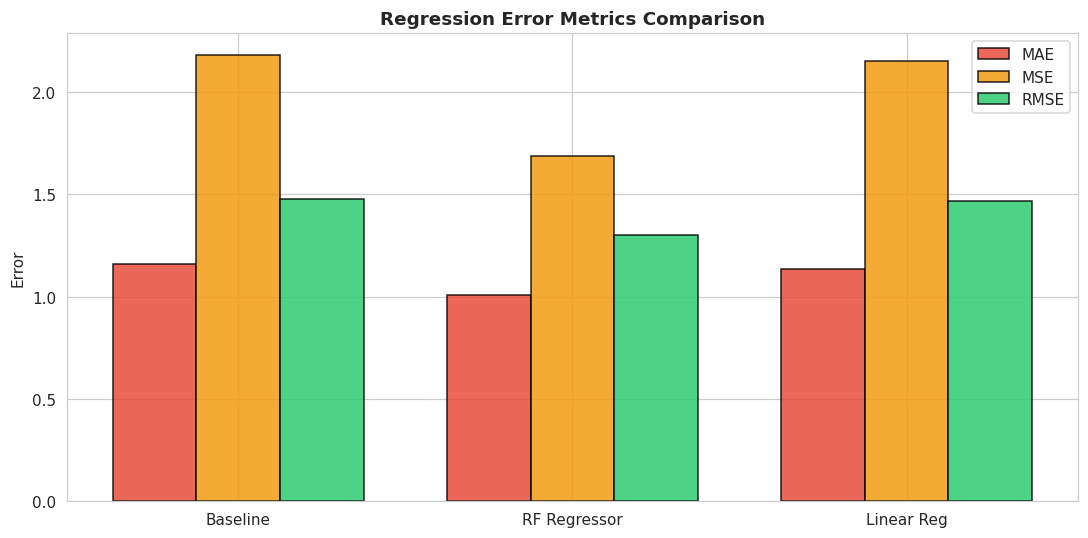

Regression predictions saved.


In [14]:
#REGRESSION: CONTINUOUS QoQ PREDICTION
y_tr_reg=df_model.loc[X_train.index,'Retail_Turnover_QoQ_Pct'].values
y_te_reg=df_model.loc[X_test.index,'Retail_Turnover_QoQ_Pct'].values

#Baseline: predict the training mean for every test row
y_base_reg=np.full(len(y_te_reg),y_tr_reg.mean())
mae_b=mean_absolute_error(y_te_reg,y_base_reg); mse_b=mean_squared_error(y_te_reg,y_base_reg); rmse_b=math.sqrt(mse_b)
print(f'--- Baseline (mean) ---  MAE={mae_b:.3f}  MSE={mse_b:.3f}  RMSE={rmse_b:.3f}')

#RF Regressor (GridSearchCV)
rfr_grid={'n_estimators':[250,500,1000],'max_depth':[10,50,100]}
rfr_cv=GridSearchCV(RandomForestRegressor(random_state=42),param_grid=rfr_grid,cv=5,
                    scoring='neg_mean_squared_error',n_jobs=-1,verbose=1)
rfr_cv.fit(X_train_sc,y_tr_reg)
print(f'Best RF Regressor params: {rfr_cv.best_params_}')
y_pred_rfr=rfr_cv.predict(X_test_sc)
mae_rfr=mean_absolute_error(y_te_reg,y_pred_rfr); mse_rfr=mean_squared_error(y_te_reg,y_pred_rfr); rmse_rfr=math.sqrt(mse_rfr)
print(f'--- RF Regressor ---  MAE={mae_rfr:.3f}  MSE={mse_rfr:.3f}  RMSE={rmse_rfr:.3f}')

#Linear Regression
lr_reg=LinearRegression(fit_intercept=True).fit(X_train_sc,y_tr_reg)
y_pred_lr=lr_reg.predict(X_test_sc)
mae_lr=mean_absolute_error(y_te_reg,y_pred_lr); mse_lr=mean_squared_error(y_te_reg,y_pred_lr); rmse_lr=math.sqrt(mse_lr)
print(f'--- Linear Regression ---  MAE={mae_lr:.3f}  MSE={mse_lr:.3f}  RMSE={rmse_lr:.3f}')

#Fig 18: actual vs predicted scatter
fig,axes=plt.subplots(1,3,figsize=(18,5))
reg_models=[('Baseline\n(Mean Predictor)',y_base_reg,mae_b,rmse_b,'#95a5a6'),
            ('RF Regressor\n(GridSearchCV)',y_pred_rfr,mae_rfr,rmse_rfr,'#27ae60'),
            ('Linear Regression',y_pred_lr,mae_lr,rmse_lr,'#2980b9')]
for ax,(name,yp,mae_v,rmse_v,col) in zip(axes,reg_models):
    ax.scatter(y_te_reg,yp,alpha=0.55,s=22,color=col,edgecolors='none')
    lo,hi=min(y_te_reg.min(),yp.min()),max(y_te_reg.max(),yp.max())
    ax.plot([lo,hi],[lo,hi],'k--',alpha=0.5,linewidth=1.2,label='Perfect fit')
    ax.set_xlabel('Actual QoQ %');ax.set_ylabel('Predicted QoQ %')
    ax.set_title(f'{name}\nMAE={mae_v:.3f}   RMSE={rmse_v:.3f}',fontweight='bold');ax.legend(fontsize=8)
fig.suptitle('Continuous Retail QoQ % Prediction — RF Regressor vs Linear vs Baseline',fontweight='bold',fontsize=13,y=1.02)
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig18.png',dpi=150,bbox_inches='tight');plt.show()

#Fig 19: error metric comparison
fig,ax=plt.subplots(figsize=(10,5))
reg_labels=['Baseline','RF Regressor','Linear Reg']
maes=[mae_b,mae_rfr,mae_lr]; mses=[mse_b,mse_rfr,mse_lr]; rmses=[rmse_b,rmse_rfr,rmse_lr]
xr=np.arange(3); wr=0.25
ax.bar(xr-wr,maes,wr,label='MAE',color='#e74c3c',edgecolor='black',alpha=0.85)
ax.bar(xr,mses,wr,label='MSE',color='#f39c12',edgecolor='black',alpha=0.85)
ax.bar(xr+wr,rmses,wr,label='RMSE',color='#2ecc71',edgecolor='black',alpha=0.85)
ax.set_xticks(xr);ax.set_xticklabels(reg_labels);ax.set_ylabel('Error')
ax.set_title('Regression Error Metrics Comparison',fontweight='bold');ax.legend()
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig19.png',dpi=150,bbox_inches='tight');plt.show()

pd.DataFrame({'Actual':np.round(y_te_reg,2),'Predicted_RF':np.round(y_pred_rfr,2),
              'Predicted_LR':np.round(y_pred_lr,2)}).to_csv(f'{OUTPUT_DIR}/regression_predictions.csv',index=False)
print('Regression predictions saved.')


Baseline RF Macro F1 (no removal): 0.4681
LOF removed 40 outliers -> RF Macro F1: 0.4230
IF removed 40 outliers -> RF Macro F1: 0.4255

--- Outlier-removal effect ---
Model                              Macro F1  vs Baseline
RF Baseline (no removal)             0.4681     same 0.0000
RF + LOF removal                     0.4230     down 0.0451
RF + Isolation Forest removal        0.4255     down 0.0426


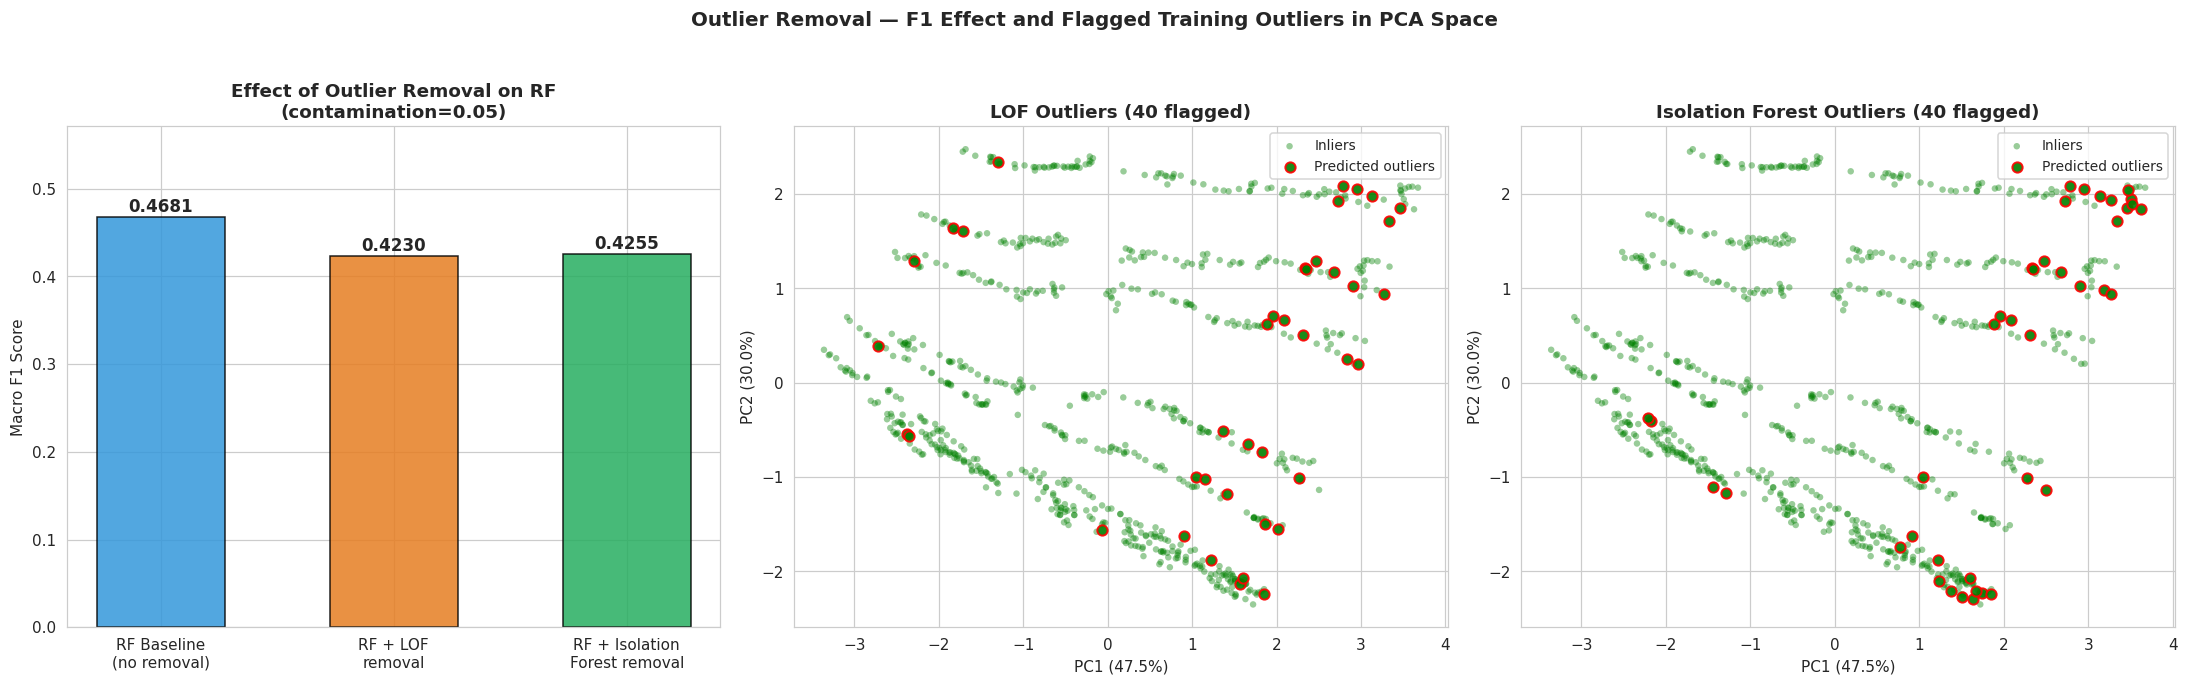


All outputs saved to /content/drive/MyDrive/PRT564_Project_Final Assessment/outputs_a4_final


In [15]:
#OUTLIER REMOVAL EFFECT ON CLASSIFIER
rf_base_f1=f1_score(y_test,rf_o.predict(X_test_sc),average='macro',zero_division=0)
print(f'Baseline RF Macro F1 (no removal): {rf_base_f1:.4f}')

#LOF removal
lof_rem=LocalOutlierFactor(n_neighbors=20,contamination=0.05)
lof_pred=lof_rem.fit_predict(X_train_sc)
mask_lof=lof_pred!=-1
rf_lof=GridSearchCV(RandomForestClassifier(random_state=42,class_weight='balanced'),
    rf_grid,cv=3,scoring='f1_macro',n_jobs=-1).fit(X_train_sc[mask_lof],y_train.values[mask_lof]).best_estimator_
lof_f1=f1_score(y_test,rf_lof.predict(X_test_sc),average='macro',zero_division=0)
print(f'LOF removed {(~mask_lof).sum()} outliers -> RF Macro F1: {lof_f1:.4f}')

#Isolation Forest removal
iso_rem=IsolationForest(contamination=0.05,random_state=42)
iso_pred=iso_rem.fit_predict(X_train_sc)
mask_iso=iso_pred!=-1
rf_iso=GridSearchCV(RandomForestClassifier(random_state=42,class_weight='balanced'),
    rf_grid,cv=3,scoring='f1_macro',n_jobs=-1).fit(X_train_sc[mask_iso],y_train.values[mask_iso]).best_estimator_
iso_f1=f1_score(y_test,rf_iso.predict(X_test_sc),average='macro',zero_division=0)
print(f'IF removed {(~mask_iso).sum()} outliers -> RF Macro F1: {iso_f1:.4f}')

print('\n--- Outlier-removal effect ---')
print(f'{"Model":<34}{"Macro F1":>9}{"vs Baseline":>13}')
for label,f1_val in [('RF Baseline (no removal)',rf_base_f1),('RF + LOF removal',lof_f1),('RF + Isolation Forest removal',iso_f1)]:
    d=f1_val-rf_base_f1; arrow='up' if d>0.001 else 'down' if d<-0.001 else 'same'
    print(f'{label:<34}{f1_val:>9.4f}{arrow:>9} {abs(d):.4f}')

#Fig 20: F1 comparison + PCA outlier visualisation
fig,(a1,a2,a3)=plt.subplots(1,3,figsize=(20,6))
labels20=['RF Baseline\n(no removal)','RF + LOF\nremoval','RF + Isolation\nForest removal']
f1_vals20=[rf_base_f1,lof_f1,iso_f1]; colors20=['#3498db','#e67e22','#27ae60']
bars20=a1.bar(labels20,f1_vals20,color=colors20,edgecolor='black',alpha=0.85,width=0.55)
a1.set_ylabel('Macro F1 Score');a1.set_title('Effect of Outlier Removal on RF\n(contamination=0.05)',fontweight='bold')
a1.set_ylim(0,max(f1_vals20)*1.22)
for b,v in zip(bars20,f1_vals20):a1.text(b.get_x()+b.get_width()/2,v+0.006,f'{v:.4f}',ha='center',fontweight='bold',fontsize=11)

out_lof=lof_pred==-1; out_iso=iso_pred==-1
for ax,om,title in [(a2,out_lof,f'LOF Outliers ({out_lof.sum()} flagged)'),
                    (a3,out_iso,f'Isolation Forest Outliers ({out_iso.sum()} flagged)')]:
    ax.scatter(Xpc_tr[~om,0],Xpc_tr[~om,1],c='green',s=18,alpha=0.40,edgecolors='none',label='Inliers')
    ax.scatter(Xpc_tr[om,0],Xpc_tr[om,1],c='green',s=45,alpha=0.90,edgecolors='red',linewidths=1.3,label='Predicted outliers')
    ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)');ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
    ax.set_title(title,fontweight='bold');ax.legend(fontsize=9)
fig.suptitle('Outlier Removal — F1 Effect and Flagged Training Outliers in PCA Space',fontweight='bold',fontsize=13,y=1.03)
plt.tight_layout();plt.savefig(f'{OUTPUT_DIR}/fig20.png',dpi=150,bbox_inches='tight');plt.show()

#Save full summary including outlier-removal models
w_rows=[
 {'Model':'RF-LOF-Removed','Train F1':f1_score(y_train.values[mask_lof],rf_lof.predict(X_train_sc[mask_lof]),average='macro',zero_division=0),
  'Test F1':lof_f1,'Gap':round(f1_score(y_train.values[mask_lof],rf_lof.predict(X_train_sc[mask_lof]),average='macro',zero_division=0)-lof_f1,4),
  'CV F1':'N/A','Acc':accuracy_score(y_test,rf_lof.predict(X_test_sc)),
  'Prec':precision_score(y_test,rf_lof.predict(X_test_sc),average='macro',zero_division=0),
  'Rec':recall_score(y_test,rf_lof.predict(X_test_sc),average='macro',zero_division=0),'ROC-AUC':'N/A'},
 {'Model':'RF-IF-Removed','Train F1':f1_score(y_train.values[mask_iso],rf_iso.predict(X_train_sc[mask_iso]),average='macro',zero_division=0),
  'Test F1':iso_f1,'Gap':round(f1_score(y_train.values[mask_iso],rf_iso.predict(X_train_sc[mask_iso]),average='macro',zero_division=0)-iso_f1,4),
  'CV F1':'N/A','Acc':accuracy_score(y_test,rf_iso.predict(X_test_sc)),
  'Prec':precision_score(y_test,rf_iso.predict(X_test_sc),average='macro',zero_division=0),
  'Rec':recall_score(y_test,rf_iso.predict(X_test_sc),average='macro',zero_division=0),'ROC-AUC':'N/A'},
]
summary_full=pd.concat([summary,pd.DataFrame(w_rows)],ignore_index=True)
summary_full.to_excel(f'{OUTPUT_DIR}/model_summary_full.xlsx',index=False)
print(f'\nAll outputs saved to {OUTPUT_DIR}')


In [16]:
#ALTERNATIVE TARGETS + COVID OUTLIER FLAG
#1c FIRST: COVID quarter flag is needed before we fit K-Means thresholds, because the COVID
#bounce-back quarters are extreme outliers that distort cluster
#centers if included. Fitting K-Means on NON-COVID retail QoQ% gives boundaries that reflect
#*normal-times* growth dynamics - this is K-Means plus outlier-aware preprocessing
covid_quarters = ['2020Q1','2020Q2','2020Q3','2020Q4','2021Q1','2021Q2','2021Q3','2021Q4']
df_model['Is_COVID'] = df_model['Quarter'].isin(covid_quarters).astype(int)

#(1a) K-Means thresholds fit on NON-COVID retail QoQ% only
non_covid_qoq = df_model.loc[df_model['Is_COVID']==0, 'Retail_Turnover_QoQ_Pct'].dropna().values.reshape(-1,1)
km_target = KMeans(n_clusters=3, random_state=42, n_init=10).fit(non_covid_qoq)
centers   = sorted(km_target.cluster_centers_.flatten().tolist())
thr_low   = (centers[0] + centers[1]) / 2
thr_high  = (centers[1] + centers[2]) / 2
print(f'K-Means cluster centers on NON-COVID retail QoQ%: {[round(c,3) for c in centers]}')
print(f'Derived class thresholds: Decline < {thr_low:.2f}%  |  Modest < {thr_high:.2f}%  |  Strong >= {thr_high:.2f}%')
print(f'(Compare with the original arbitrary cuts: 0%, 1%)')

def cg_km(q):
    if pd.isna(q): return np.nan
    if q < thr_low:  return 'Decline'
    if q < thr_high: return 'Modest Growth'
    return 'Strong Growth'
df_model['Growth_State_KM'] = df_model['Retail_Turnover_QoQ_Pct'].apply(cg_km)

#(1b) Binary target - Decline vs Growth
df_model['Growth_State_Binary'] = df_model['Retail_Turnover_QoQ_Pct'].apply(
    lambda q: np.nan if pd.isna(q) else ('Decline' if q < 0 else 'Growth'))

#(1c) df_nocovid built from the flag set above
df_nocovid = df_model[df_model['Is_COVID']==0].copy().reset_index(drop=True)

print()
print('TARGET DISTRIBUTIONS')
print('-'*68)
print(f'Original 3-class (with COVID, n={len(df_model)}):')
for k,v in df_model['Growth_State'].value_counts().items():       print(f'   {k:<14} {v}')
print(f'\nK-Means 3-class (with COVID, n={len(df_model)}):')
for k,v in df_model['Growth_State_KM'].value_counts().items():    print(f'   {k:<14} {v}')
print(f'\nBinary (with COVID, n={len(df_model)}):')
for k,v in df_model['Growth_State_Binary'].value_counts().items():print(f'   {k:<14} {v}')

print()
print('COVID OUTLIER FLAG')
print('-'*68)
print(f'COVID quarters identified: {df_model["Is_COVID"].sum()} rows ({df_model["Is_COVID"].mean()*100:.1f}% of dataset)')
print(f'Per state row counts:')
for s,n in df_model.groupby('State')['Is_COVID'].sum().items(): print(f'   {s}: {n}')
print(f'\nNon-COVID dataset: {len(df_nocovid)} rows')
print(f'Non-COVID 3-class:    {df_nocovid["Growth_State"].value_counts().to_dict()}')
print(f'Non-COVID binary:     {df_nocovid["Growth_State_Binary"].value_counts().to_dict()}')


K-Means cluster centers on NON-COVID retail QoQ%: [-0.84, 0.857, 2.807]
Derived class thresholds: Decline < 0.01%  |  Modest < 1.83%  |  Strong >= 1.83%
(Compare with the original arbitrary cuts: 0%, 1%)

TARGET DISTRIBUTIONS
--------------------------------------------------------------------
Original 3-class (with COVID, n=872):
   Strong Growth  343
   Decline        275
   Modest Growth  254

K-Means 3-class (with COVID, n=872):
   Modest Growth  408
   Decline        278
   Strong Growth  186

Binary (with COVID, n=872):
   Growth         597
   Decline        275

COVID OUTLIER FLAG
--------------------------------------------------------------------
COVID quarters identified: 64 rows (7.3% of dataset)
Per state row counts:
   ACT: 8
   NSW: 8
   NT: 8
   QLD: 8
   SA: 8
   TAS: 8
   VIC: 8
   WA: 8

Non-COVID dataset: 808 rows
Non-COVID 3-class:    {'Strong Growth': 316, 'Decline': 248, 'Modest Growth': 244}
Non-COVID binary:     {'Growth': 560, 'Decline': 248}


In [17]:
#K-MEANS CLUSTER ID AS FEATURE + FORWARD SELECTION
#K-Means on the standardised macro feature block produces a regime label per quarter.
#We use k=4 to allow for: expansion, slowdown, contraction, crisis. Justified by the elbow
#check from Figure 6
numeric_for_regime = [c for c in feature_cols if c not in state_cols]
X_regime_src = df_model[numeric_for_regime].astype(float).values
X_regime_sc  = StandardScaler().fit_transform(X_regime_src)
km_regime    = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_regime_sc)
df_model['Macro_Regime'] = km_regime.labels_

#One-hot encode the regime label as Regime_1, Regime_2, Regime_3
regime_dummies = pd.get_dummies(df_model['Macro_Regime'], prefix='Regime', drop_first=True, dtype=int)
df_model = pd.concat([df_model, regime_dummies], axis=1)
regime_cols = list(regime_dummies.columns)

#Propagate to df_nocovid
df_nocovid = df_model[df_model['Is_COVID']==0].copy().reset_index(drop=True)

print(f'K-Means macro regimes (k=4): assigned to all {len(df_model)} rows')
print(f'Added {len(regime_cols)} regime dummies: {regime_cols}')
print(f'Cluster sizes: {df_model["Macro_Regime"].value_counts().sort_index().to_dict()}')
print()
print('Regime composition by Growth_State (with COVID):')
print(pd.crosstab(df_model['Macro_Regime'], df_model['Growth_State']))

#FORWARD SELECTION
import statsmodels.api as sm
y_num_fs = df_model['Growth_State'].map({'Decline':-1,'Modest Growth':0,'Strong Growth':1}).values
X_fs     = df_model[feature_cols].astype(float)
remaining_fs = list(X_fs.columns)
selected_fs  = []
ALPHA_FS = 0.10
while remaining_fs:
    best_p, best_feat = 1.0, None
    for feat in remaining_fs:
        try:
            Xc = sm.add_constant(X_fs[selected_fs + [feat]])
            res = sm.OLS(y_num_fs, Xc).fit()
            p = res.pvalues[feat]
            if p < best_p:
                best_p, best_feat = p, feat
        except Exception:
            continue
    if best_p < ALPHA_FS and best_feat is not None:
        selected_fs.append(best_feat)
        remaining_fs.remove(best_feat)
    else:
        break

#'remaining' from the earlier backward-elimination cell holds the BE survivors
be_set, fs_set = set(remaining), set(selected_fs)
intersection_feats = sorted(be_set & fs_set)
union_feats        = sorted(be_set | fs_set)

print(f'\nForward selection kept {len(selected_fs)}/{len(feature_cols)} features (alpha={ALPHA_FS})')
print(f'Backward elimination survivors (from earlier cell): {len(be_set)}')
print(f'Forward selection survivors:                       {len(fs_set)}')
print(f'INTERSECTION (robust feature set):                 {len(intersection_feats)}')
print(f'\nRobust features in BOTH backward and forward selection:')
for f in intersection_feats: print(f'  ** {f}')
pd.Series(intersection_feats, name='robust_feature_set').to_csv(f'{OUTPUT_DIR}/robust_feature_set.csv', index=False)


K-Means macro regimes (k=4): assigned to all 872 rows
Added 3 regime dummies: ['Regime_1', 'Regime_2', 'Regime_3']
Cluster sizes: {0: 300, 1: 316, 2: 216, 3: 40}

Regime composition by Growth_State (with COVID):
Growth_State  Decline  Modest Growth  Strong Growth
Macro_Regime                                       
0                 100            115             85
1                  80             66            170
2                  77             60             79
3                  18             13              9

Forward selection kept 5/25 features (alpha=0.1)
Backward elimination survivors (from earlier cell): 13
Forward selection survivors:                       5
INTERSECTION (robust feature set):                 4

Robust features in BOTH backward and forward selection:
  ** CPI_All_Groups_Index
  ** CPI_QoQ_Pct
  ** Population_QoQ_Pct
  ** State_Final_Demand_QoQ_Pct


Running variant A (baseline -- current notebook state)...
Running variant B (K-Means thresholds)...
Running variant C (binary, COVID in)...
Running variant D (binary, COVID out)...
Running variant E (binary, COVID out, +Regime feature)...
Running variant F (binary, COVID out, +Regime, robust feature set) -- this is the FINAL model basis

SIDE-BY-SIDE COMPARISON  (CV F1 mean is the headline reliability metric)
                            Variant              Target  n_class  n_rows  n_feat  Dummy F1  Dummy Acc  Test F1  Test Acc  CV F1 mean  CV F1 std  Lift vs Dummy (CV)
   A. Baseline 3-class (0%/1% cuts)        Growth_State        3     872      25     0.186      0.386    0.461     0.477       0.490      0.037               0.304
      B. K-Means 3-class thresholds     Growth_State_KM        3     872      25     0.212      0.466    0.501     0.500       0.494      0.038               0.282
      C. Binary (Decline vs Growth) Growth_State_Binary        2     872      25     0.405     

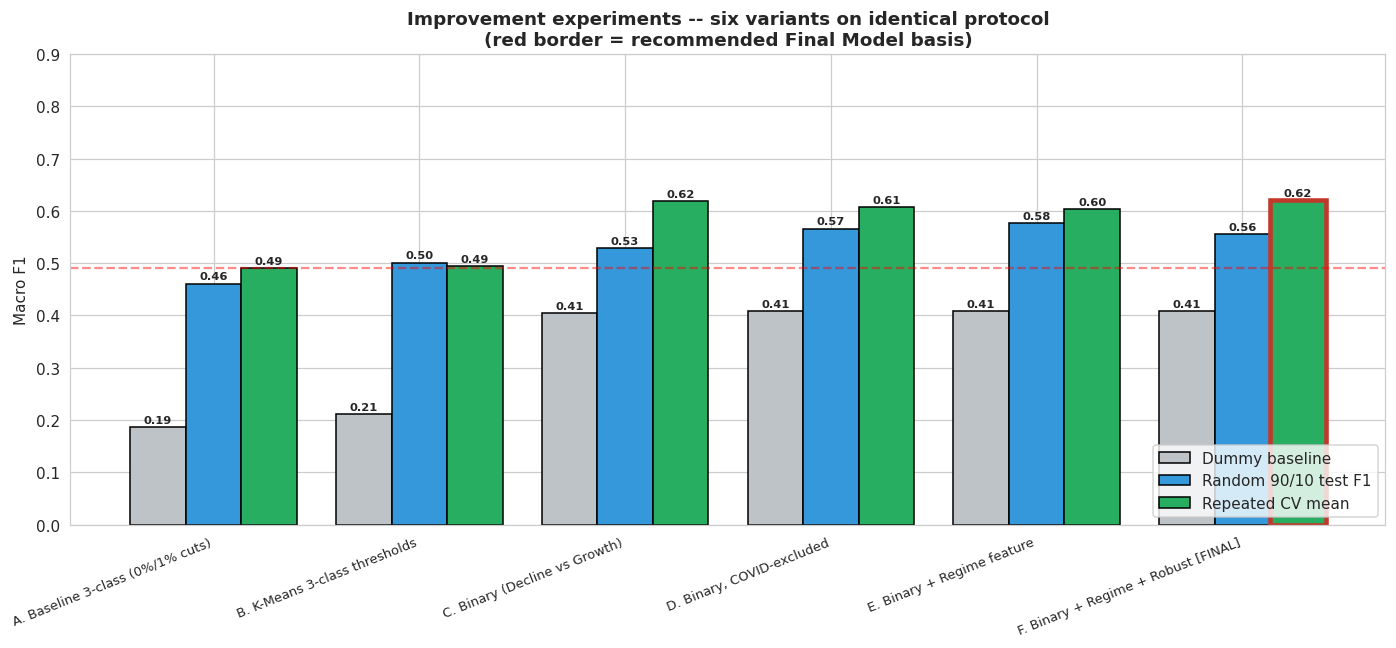

In [18]:
#SIDE-BY-SIDE COMPARISON
def eval_variant(label, target_col, df_use, feature_set):
    df_v = df_use.dropna(subset=feature_set + [target_col]).reset_index(drop=True)
    if df_v[target_col].nunique() < 2 or len(df_v) < 60:
        return None
    X = df_v[feature_set].astype(float)
    y = df_v[target_col]

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)
    sc = StandardScaler()
    Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)

    rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=10,
                                max_features='sqrt', class_weight='balanced',
                                random_state=42, n_jobs=-1).fit(Xtr_s, ytr)

    test_f1  = f1_score(yte, rf.predict(Xte_s), average='macro', zero_division=0)
    test_acc = accuracy_score(yte, rf.predict(Xte_s))

    #Repeated CV: 5 reps x 5 folds = 25 estimates for the comparison sweep
    cv_scores = []
    X_all_sc = sc.transform(X)
    for seed in range(5):
        sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        cv_scores.extend(cross_val_score(rf, X_all_sc, y, cv=sk, scoring='f1_macro', n_jobs=-1))
    cv_mean, cv_std = float(np.mean(cv_scores)), float(np.std(cv_scores, ddof=1))

    dummy = DummyClassifier(strategy='most_frequent', random_state=42).fit(Xtr_s, ytr)
    dummy_f1  = f1_score(yte, dummy.predict(Xte_s), average='macro', zero_division=0)
    dummy_acc = accuracy_score(yte, dummy.predict(Xte_s))

    return {
        'Variant': label, 'Target': target_col, 'n_class': y.nunique(),
        'n_rows': len(df_v), 'n_feat': len(feature_set),
        'Dummy F1': round(dummy_f1, 3), 'Dummy Acc': round(dummy_acc, 3),
        'Test F1': round(test_f1, 3), 'Test Acc': round(test_acc, 3),
        'CV F1 mean': round(cv_mean, 3), 'CV F1 std': round(cv_std, 3),
        'Lift vs Dummy (CV)': round(cv_mean - dummy_f1, 3),
    }

variants = []
print('Running variant A (baseline -- current notebook state)...')
variants.append(eval_variant('A. Baseline 3-class (0%/1% cuts)',
                             'Growth_State',        df_model,   feature_cols))
print('Running variant B (K-Means thresholds)...')
variants.append(eval_variant('B. K-Means 3-class thresholds',
                             'Growth_State_KM',     df_model,   feature_cols))
print('Running variant C (binary, COVID in)...')
variants.append(eval_variant('C. Binary (Decline vs Growth)',
                             'Growth_State_Binary', df_model,   feature_cols))
print('Running variant D (binary, COVID out)...')
variants.append(eval_variant('D. Binary, COVID-excluded',
                             'Growth_State_Binary', df_nocovid, feature_cols))
print('Running variant E (binary, COVID out, +Regime feature)...')
variants.append(eval_variant('E. Binary + Regime feature',
                             'Growth_State_Binary', df_nocovid, feature_cols + regime_cols))
print('Running variant F (binary, COVID out, +Regime, robust feature set) -- this is the FINAL model basis')
robust_plus_regime = sorted(set(intersection_feats) | set(regime_cols) | set(state_cols))
variants.append(eval_variant('F. Binary + Regime + Robust [FINAL]',
                             'Growth_State_Binary', df_nocovid, robust_plus_regime))

comp = pd.DataFrame([v for v in variants if v is not None])
print()
print('='*98)
print('SIDE-BY-SIDE COMPARISON  (CV F1 mean is the headline reliability metric)')
print('='*98)
print(comp.to_string(index=False))
print('='*98)
comp.to_excel(f'{OUTPUT_DIR}/improvement_comparison.xlsx', index=False)

#Visualisation: 3 bars per variant (Dummy/Test F1/CV mean)
fig, ax = plt.subplots(figsize=(13, 6))
xv = np.arange(len(comp))
w  = 0.27
bars1 = ax.bar(xv - w, comp['Dummy F1'],   w, label='Dummy baseline',       color='#bdc3c7', edgecolor='black')
bars2 = ax.bar(xv,     comp['Test F1'],    w, label='Random 90/10 test F1', color='#3498db', edgecolor='black')
bars3 = ax.bar(xv + w, comp['CV F1 mean'], w, label='Repeated CV mean',     color='#27ae60', edgecolor='black')

bars3[-1].set_edgecolor('#c0392b'); bars3[-1].set_linewidth(3)
ax.set_xticks(xv); ax.set_xticklabels(comp['Variant'], rotation=22, ha='right', fontsize=8.5)
ax.set_ylabel('Macro F1'); ax.set_ylim(0, max(comp[['Test F1','CV F1 mean']].values.max() * 1.20, 0.9))
ax.set_title('Improvement experiments -- six variants on identical protocol\n(red border = recommended Final Model basis)',
             fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.axhline(comp.iloc[0]['CV F1 mean'], color='red', ls='--', alpha=0.45)

#annotate
for i,row in comp.iterrows():
    for off,col in zip([-w, 0, w], ['Dummy F1','Test F1','CV F1 mean']):
        ax.text(i+off, row[col]+0.008, f'{row[col]:.2f}', ha='center', fontsize=7.5, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/fig_improvements.png', dpi=150, bbox_inches='tight'); plt.show()


REGRESSION -> THRESHOLD vs DIRECT CLASSIFIER (10% held-out test set)
------------------------------------------------------------------------
                                Approach  Macro F1  Accuracy
  Direct RF Classifier (original target)     0.468     0.489
  RF Regressor -> threshold (0%/1% cuts)     0.326     0.364
RF Regressor -> threshold (K-Means cuts)     0.309     0.466
------------------------------------------------------------------------


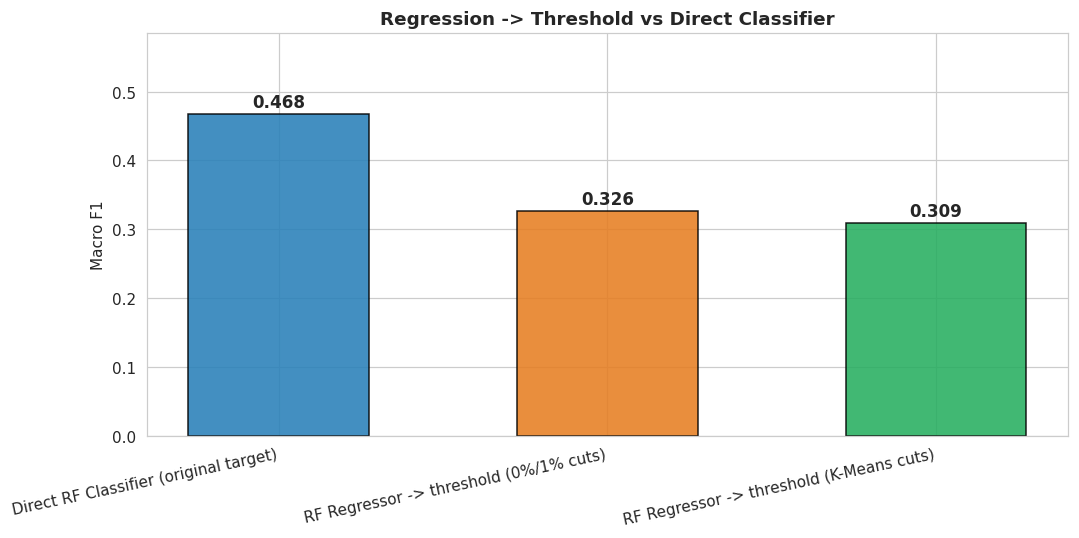

In [19]:
#REGRESSION > CLASSIFIER via THRESHOLDING
#The RF Regressor from cell 27 produced y_pred_rfr on the held-out 10% test set
#(X_train_sc / X_test_sc; the original Growth_State 3-class target).
#Apply both threshold schemes and convert to class labels:

def discretise(pred_values, low, high):
    return np.where(pred_values < low, 'Decline',
           np.where(pred_values < high, 'Modest Growth', 'Strong Growth'))

#(a) Original arbitrary thresholds (0% and 1%)
yhat_class_orig = discretise(y_pred_rfr, 0.0, 1.0)
#(b) K-Means-derived thresholds (from lever #1)
yhat_class_km   = discretise(y_pred_rfr, thr_low, thr_high)

#Compare against the direct RF Classifier predictions on the same test set
rf_classifier_orig = next(r for r in results if r['name']=='RF-Orig')
y_pred_direct = rf_classifier_orig['y_pred']

#Also compute the equivalent on the actual continuous target (gold-standard target labels under each scheme)
y_test_orig_labels = y_test.values   # already the original 3-class labels
y_test_km_labels   = discretise(df_model.loc[X_test.index,'Retail_Turnover_QoQ_Pct'].values, thr_low, thr_high)

reg_thr_rows = [
    {'Approach':'Direct RF Classifier (original target)',
     'Macro F1': round(f1_score(y_test_orig_labels, y_pred_direct, average='macro', zero_division=0), 3),
     'Accuracy':  round(accuracy_score(y_test_orig_labels, y_pred_direct), 3)},
    {'Approach':'RF Regressor -> threshold (0%/1% cuts)',
     'Macro F1': round(f1_score(y_test_orig_labels, yhat_class_orig, average='macro', zero_division=0), 3),
     'Accuracy':  round(accuracy_score(y_test_orig_labels, yhat_class_orig), 3)},
    {'Approach':'RF Regressor -> threshold (K-Means cuts)',
     'Macro F1': round(f1_score(y_test_km_labels,   yhat_class_km,   average='macro', zero_division=0), 3),
     'Accuracy':  round(accuracy_score(y_test_km_labels,   yhat_class_km), 3)},
]
reg_thr_df = pd.DataFrame(reg_thr_rows)
print('REGRESSION -> THRESHOLD vs DIRECT CLASSIFIER (10% held-out test set)')
print('-'*72)
print(reg_thr_df.to_string(index=False))
print('-'*72)
reg_thr_df.to_excel(f'{OUTPUT_DIR}/regression_to_threshold.xlsx', index=False)

#Visualise
fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(reg_thr_df['Approach'], reg_thr_df['Macro F1'],
              color=['#2980b9','#e67e22','#27ae60'], edgecolor='black', alpha=0.88, width=0.55)
for b,v in zip(bars, reg_thr_df['Macro F1']):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Macro F1'); ax.set_ylim(0, max(reg_thr_df['Macro F1'])*1.25)
ax.set_title('Regression -> Threshold vs Direct Classifier', fontweight='bold')
plt.xticks(rotation=12, ha='right')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/fig_reg_threshold.png', dpi=150, bbox_inches='tight'); plt.show()


Final-model dataset: 808 rows (COVID-excluded), 14 features
  Train: 727   Test: 81
  Class balance: {'Growth': 560, 'Decline': 248}

Tuned DT  : depth=7  leaf=5  criterion=gini
Tuned RF  : depth=4  leaf=15  n=500  feat=sqrt
Tuned SVM : C=5  kernel=rbf  gamma=0.01

Running 10x10 repeated CV (100 estimates per model)...
  Dummy (baseline)     done
  Naive Bayes          done
  Decision Tree        done
  Random Forest        done
  SVM                  done

FINAL MODEL RESULTS  (binary: Decline vs Growth, COVID-excluded, robust features)
           Model  Train F1  Test F1  Accuracy  Precision  Recall  CV mean  CV std  CV 95% lo  CV 95% hi  ROC-AUC
Dummy (baseline)     0.409    0.409     0.691      0.346   0.500    0.409   0.002      0.407      0.411    0.500
     Naive Bayes     0.588    0.575     0.654      0.581   0.573    0.568   0.054      0.468      0.689    0.607
   Decision Tree     0.728    0.509     0.556      0.511   0.512    0.572   0.060      0.448      0.695    0.524
   R

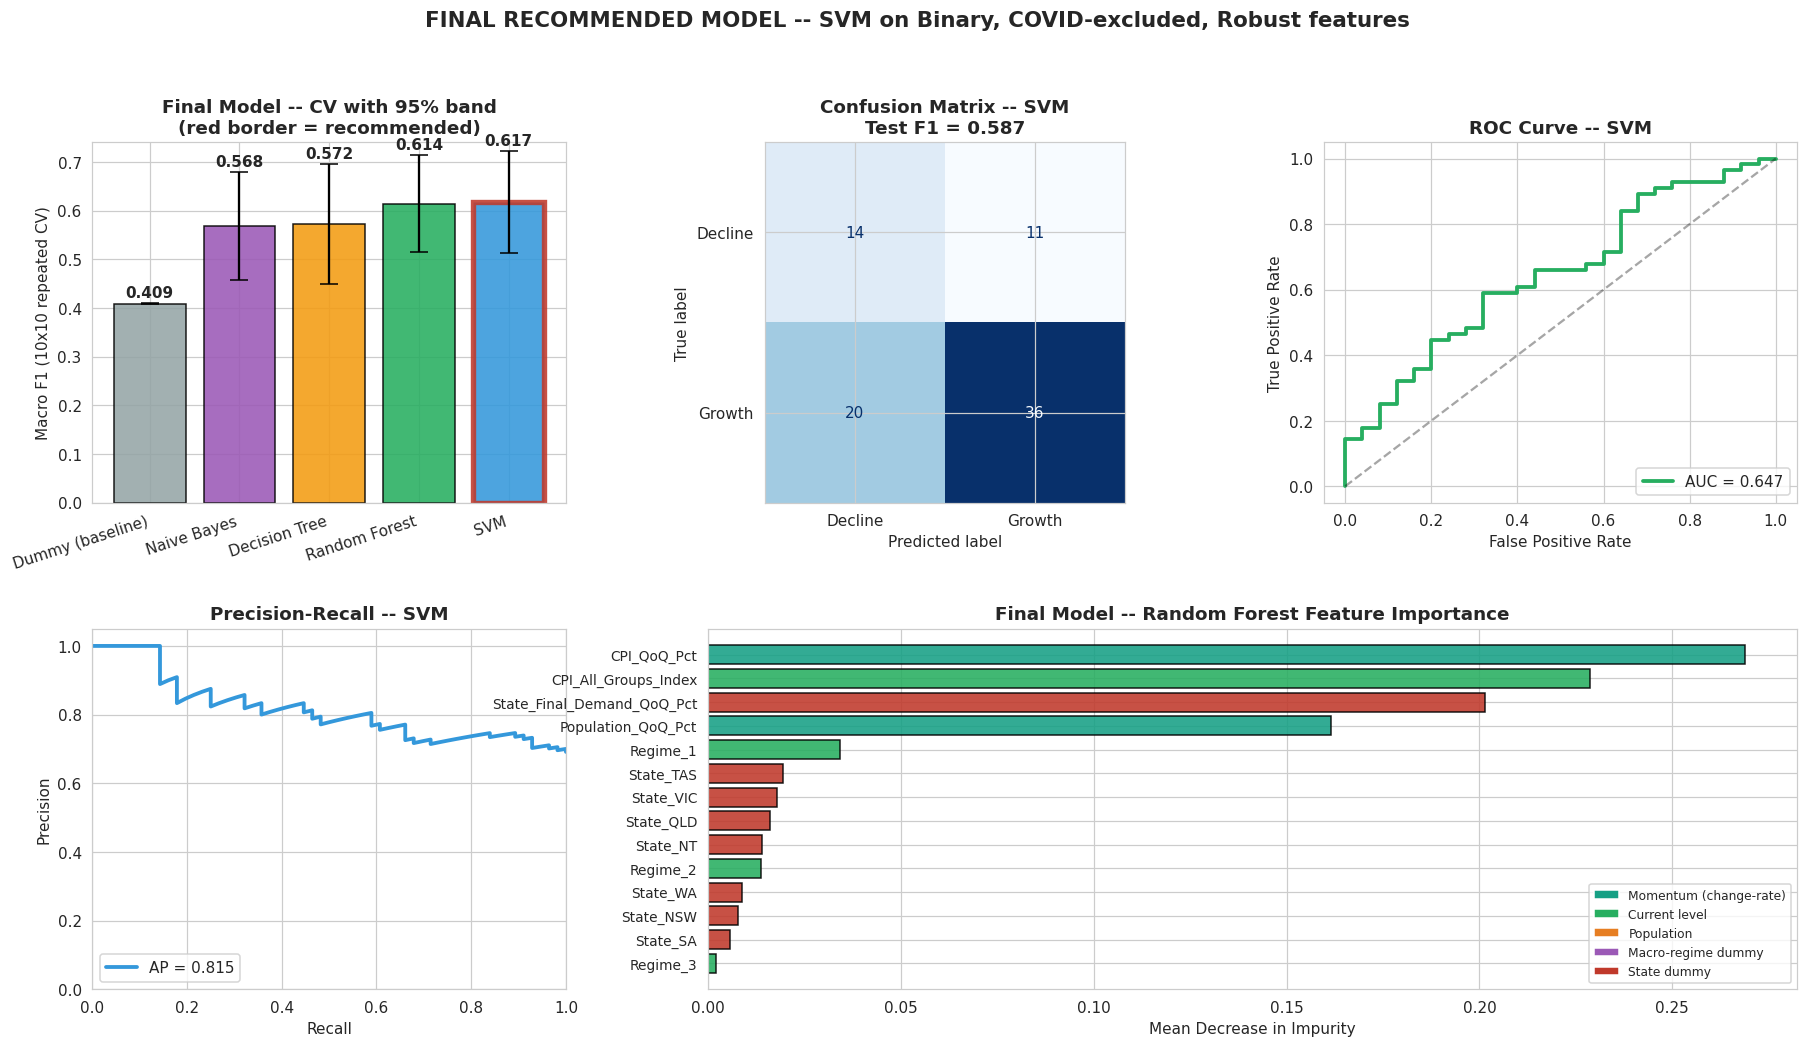

In [20]:
#RECOMMENDED MODEL
#Binary target + COVID-excluded panel + robust features + regime + state dummies
final_features = sorted(set(intersection_feats) | set(regime_cols) | set(state_cols))
df_final = df_nocovid.dropna(subset=final_features + ['Growth_State_Binary']).reset_index(drop=True)
Xf = df_final[final_features].astype(float)
yf = df_final['Growth_State_Binary']

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.10, random_state=42, stratify=yf)
scf = StandardScaler()
Xf_tr_s = scf.fit_transform(Xf_tr); Xf_te_s = scf.transform(Xf_te)

print(f'Final-model dataset: {len(df_final)} rows (COVID-excluded), {len(final_features)} features')
print(f'  Train: {len(Xf_tr)}   Test: {len(Xf_te)}')
print(f'  Class balance: {yf.value_counts().to_dict()}')
print()

#Majority-class baseline
dum_f = DummyClassifier(strategy='most_frequent', random_state=42).fit(Xf_tr_s, yf_tr)

#Gaussian Naive Bayes - no hyperparameters to tune
nb_f = GaussianNB().fit(Xf_tr_s, yf_tr)

#Decision Tree
dt_grid_f = {'max_depth':[3,5,7,10,15], 'min_samples_split':[10,20,40],
             'min_samples_leaf':[5,10,20], 'criterion':['gini','entropy']}
dt_f = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'),
                    dt_grid_f, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                    scoring='f1_macro', n_jobs=-1).fit(Xf_tr_s, yf_tr).best_estimator_

#Random Forest
rf_grid_f = {'n_estimators':[300,500,800], 'max_depth':[4,6,8,10,12],
             'min_samples_split':[5,10,20], 'min_samples_leaf':[3,5,10,15],
             'max_features':['sqrt','log2']}
rf_f = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
                    rf_grid_f, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                    scoring='f1_macro', n_jobs=-1).fit(Xf_tr_s, yf_tr).best_estimator_

#Support Vector Machine
svm_grid_f = {'C':[0.1,0.5,1,5,10,50], 'kernel':['rbf','linear'], 'gamma':['scale','auto',0.01,0.1]}
svm_f = GridSearchCV(SVC(probability=True, random_state=42, class_weight='balanced'),
                     svm_grid_f, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='f1_macro', n_jobs=-1).fit(Xf_tr_s, yf_tr).best_estimator_

print(f'Tuned DT  : depth={dt_f.max_depth}  leaf={dt_f.min_samples_leaf}  criterion={dt_f.criterion}')
print(f'Tuned RF  : depth={rf_f.max_depth}  leaf={rf_f.min_samples_leaf}  n={rf_f.n_estimators}  feat={rf_f.max_features}')
print(f'Tuned SVM : C={svm_f.C}  kernel={svm_f.kernel}  gamma={svm_f.gamma}')
print()

#Repeated 10x10 CV reliability metric on all five learners
final_models = [('Dummy (baseline)', dum_f),
                ('Naive Bayes',      nb_f),
                ('Decision Tree',    dt_f),
                ('Random Forest',    rf_f),
                ('SVM',              svm_f)]
final_results = []
print('Running 10x10 repeated CV (100 estimates per model)...')
for name, mdl in final_models:
    yp = mdl.predict(Xf_te_s)
    try:
        ypr = mdl.predict_proba(Xf_te_s)
        # binary ROC-AUC
        pos_idx = list(mdl.classes_).index('Growth')
        roc = roc_auc_score((yf_te=='Growth').astype(int), ypr[:, pos_idx])
    except Exception:
        ypr, roc = None, np.nan

    cv_scores = repeated_cv_f1(mdl, Xf_tr_s, yf_tr, n_folds=10, n_reps=10, seed_base=42)
    summ = cv_summary(cv_scores)

    final_results.append({
        'Model': name, 'mdl': mdl, 'y_pred': yp, 'y_prob': ypr,
        'Train F1': round(f1_score(yf_tr, mdl.predict(Xf_tr_s), average='macro', zero_division=0), 3),
        'Test F1':  round(f1_score(yf_te, yp,                   average='macro', zero_division=0), 3),
        'Accuracy': round(accuracy_score(yf_te, yp), 3),
        'Precision':round(precision_score(yf_te, yp, average='macro', zero_division=0), 3),
        'Recall':   round(recall_score(yf_te, yp, average='macro', zero_division=0), 3),
        'CV mean':  round(summ['mean'], 3),
        'CV std':   round(summ['std'], 3),
        'CV 95% lo':round(summ['lo'], 3),
        'CV 95% hi':round(summ['hi'], 3),
        'ROC-AUC':  round(roc, 3) if not np.isnan(roc) else 'N/A',
    })
    print(f'  {name:<20} done')

print()
print('='*108)
print('FINAL MODEL RESULTS  (binary: Decline vs Growth, COVID-excluded, robust features)')
print('='*108)
final_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ('mdl','y_pred','y_prob')} for r in final_results])
print(final_df.to_string(index=False))
print('='*108)
final_df.to_excel(f'{OUTPUT_DIR}/final_model_results.xlsx', index=False)

best_final = max([r for r in final_results if r['Model']!='Dummy (baseline)'], key=lambda r: r['CV mean'])
print(f'\n*** RECOMMENDED MODEL: {best_final["Model"]} ***')
print(f'    CV macro F1:  {best_final["CV mean"]:.3f} +/- {best_final["CV std"]:.3f}  (95% band: [{best_final["CV 95% lo"]:.3f}, {best_final["CV 95% hi"]:.3f}])')
print(f'    Test F1:      {best_final["Test F1"]:.3f}')
print(f'    Test Acc:     {best_final["Accuracy"]:.3f}')
print(f'    ROC-AUC:      {best_final["ROC-AUC"]}')
print(f'    Baseline F1:  {next(r for r in final_results if r["Model"]=="Dummy (baseline)")["CV mean"]:.3f}  (the model must beat this)')
print(f'    Lift vs base: {best_final["CV mean"] - next(r for r in final_results if r["Model"]=="Dummy (baseline)")["CV mean"]:+.3f}')

#Classification report
print(f'\nClassification report on the 10% held-out test set ({best_final["Model"]}):')
print(classification_report(yf_te, best_final['y_pred'], zero_division=0))

#Figure: model comparison + confusion matrix + ROC + PR for the best model
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.30)

#Panel 1: CV F1 with 95% bands across the five learners
ax1 = fig.add_subplot(gs[0, 0])
names = [r['Model'] for r in final_results]
means = [r['CV mean'] for r in final_results]
errs  = [(r['CV 95% hi'] - r['CV 95% lo'])/2 for r in final_results]
colors= ['#95a5a6', '#9b59b6', '#f39c12', '#27ae60', '#3498db']
bars = ax1.bar(range(len(names)), means, yerr=errs, capsize=6,
               color=colors, edgecolor='black', alpha=0.88)
best_idx = max(range(1, len(final_results)), key=lambda i: final_results[i]['CV mean'])
bars[best_idx].set_edgecolor('#c0392b'); bars[best_idx].set_linewidth(3.5)
ax1.set_xticks(range(len(names))); ax1.set_xticklabels(names, rotation=18, ha='right', fontsize=10)
ax1.set_ylabel('Macro F1 (10x10 repeated CV)')
ax1.set_title('Final Model -- CV with 95% band\n(red border = recommended)', fontweight='bold')
ax1.set_ylim(0, max(means)*1.20)
for i,(m,e) in enumerate(zip(means,errs)):
    ax1.text(i, m+e+0.012, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')

#Panel 2: Confusion matrix of best model
ax2 = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(yf_te, best_final['y_pred'], labels=['Decline','Growth'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Decline','Growth'])
disp.plot(ax=ax2, cmap='Blues', colorbar=False)
ax2.set_title(f'Confusion Matrix -- {best_final["Model"]}\nTest F1 = {best_final["Test F1"]:.3f}', fontweight='bold')

#Panel 3: ROC for best model
ax3 = fig.add_subplot(gs[0, 2])
pos_idx = list(best_final['mdl'].classes_).index('Growth')
fpr,tpr,_ = roc_curve((yf_te=='Growth').astype(int), best_final['y_prob'][:, pos_idx])
ax3.plot(fpr,tpr, linewidth=2.5, color='#27ae60', label=f'AUC = {auc(fpr,tpr):.3f}')
ax3.plot([0,1],[0,1],'k--',alpha=0.35)
ax3.set_xlabel('False Positive Rate'); ax3.set_ylabel('True Positive Rate')
ax3.set_title(f'ROC Curve -- {best_final["Model"]}', fontweight='bold')
ax3.legend(loc='lower right')

#Panel 4: Precision-Recall for best model
ax4 = fig.add_subplot(gs[1, 0])
pr,rc,_ = precision_recall_curve((yf_te=='Growth').astype(int), best_final['y_prob'][:, pos_idx])
ap = average_precision_score((yf_te=='Growth').astype(int), best_final['y_prob'][:, pos_idx])
ax4.plot(rc, pr, linewidth=2.5, color='#3498db', label=f'AP = {ap:.3f}')
ax4.set_xlabel('Recall'); ax4.set_ylabel('Precision')
ax4.set_title(f'Precision-Recall -- {best_final["Model"]}', fontweight='bold')
ax4.legend(loc='lower left'); ax4.set_xlim([0,1]); ax4.set_ylim([0,1.05])

#Panel 5: Feature importance
ax5 = fig.add_subplot(gs[1, 1:])
if hasattr(rf_f, 'feature_importances_'):
    fi = pd.Series(rf_f.feature_importances_, index=final_features).sort_values(ascending=True)
    cols_fi = [fc(n) for n in fi.index]
    ax5.barh(range(len(fi)), fi.values, color=cols_fi, edgecolor='black', alpha=0.88)
    ax5.set_yticks(range(len(fi))); ax5.set_yticklabels(fi.index, fontsize=9)
    ax5.set_xlabel('Mean Decrease in Impurity'); ax5.set_title('Final Model -- Random Forest Feature Importance', fontweight='bold')
    ax5.legend(handles=[Patch(facecolor='#16a085',label='Momentum (change-rate)'),
                        Patch(facecolor='#27ae60',label='Current level'),
                        Patch(facecolor='#e67e22',label='Population'),
                        Patch(facecolor='#9b59b6',label='Macro-regime dummy'),
                        Patch(facecolor='#c0392b',label='State dummy')],
              fontsize=8, loc='lower right')

plt.suptitle(f'FINAL RECOMMENDED MODEL -- {best_final["Model"]} on Binary, COVID-excluded, Robust features',
             fontweight='bold', fontsize=14, y=1.00)
plt.savefig(f'{OUTPUT_DIR}/fig_final_model.png', dpi=150, bbox_inches='tight'); plt.show()
